# Final Synthesis — Electoral Volatility Deep-Dive II

**Closing Analysis:** Temporal Dynamics, Model Robustness & the Complete Story

**Author:** Antoni Czolgowski | March 2026 | CSCI 5502 Data Mining

**Dataset:** 250 counties (PA 67, MI 83, NC 100) | 28 demographic features | 3 election cycles (2016, 2020, 2024)

---

This notebook closes the classification analysis by adding:
1. **Temporal analysis** — how demographics shifted 2016→2024 and whether change predicts volatility
2. **Election trajectories** — margin movement patterns across 3 cycles
3. **Partial dependence** — the true functional shape of feature effects
4. **Statistical robustness** — bootstrap CIs and feature group ablation
5. **Ensemble stacking** — pushing the performance ceiling
6. **Diversity threshold** — precise estimation with confidence intervals
7. **SHAP-based archetypes** — data-driven county clustering from model explanations
8. **Grand synthesis** — one figure that tells the complete story

In [1]:
import numpy as np
import pandas as pd
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import xgboost as xgb
import shap

from scipy.stats import pearsonr, spearmanr, mannwhitneyu, kruskal

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
warnings.filterwarnings('ignore')

BASE = '../data/processed'
FIG_DIR = '../docs/images/methods'
os.makedirs(FIG_DIR, exist_ok=True)

# Publication-quality palettes
STATE_COLORS = {'PA': '#2166ac', 'MI': '#ef8a62', 'NC': '#4dac26'}
VOL_CMAP = sns.color_palette(['#2166ac', '#67a9cf', '#d1d1d1', '#ef8a62', '#b2182b'])
BINARY_COLORS = {'Low': '#2166ac', 'High': '#b2182b'}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load all datasets ──
master = pd.read_csv(f'{BASE}/master_dataset.csv', dtype={'county_fips': str})
master['county_fips'] = master['county_fips'].str.zfill(5)

class_df = pd.read_csv(f'{BASE}/classification_dataset_250.csv', dtype={'county_fips': str})
class_df['county_fips'] = class_df['county_fips'].str.zfill(5)

vol_dim = pd.read_csv(f'{BASE}/county_volatility_dimTable.csv', dtype={'county_fips': str})
vol_dim['county_fips'] = vol_dim['county_fips'].str.zfill(5)

preds_df = pd.read_csv(f'{BASE}/classification_predictions.csv', dtype={'county_fips': str})
preds_df['county_fips'] = preds_df['county_fips'].str.zfill(5)

priority_df = pd.read_csv(f'{BASE}/campaign_priority_rankings.csv', dtype={'county_fips': str})
priority_df['county_fips'] = priority_df['county_fips'].str.zfill(5)

# ── Build analysis DataFrame ──
df = class_df.copy()

# Merge volatility details
vol_cols = ['county_fips', 'dem_margin_2016', 'dem_margin_2020', 'dem_margin_2024',
            'd_16_20', 'd_20_24', 'swing_dir_score']
df = df.merge(vol_dim[vol_cols], on='county_fips', how='left')

# Merge predictions + misfit
pred_cols = ['county_fips', 'rf_pred', 'xgb_pred', 'svm_pred', 'p_dem', 'misfit_score']
df = df.merge(preds_df[pred_cols], on='county_fips', how='left')

# Merge priority
pri_cols = ['county_fips', 'priority_score']
if 'priority_score' in priority_df.columns:
    df = df.merge(priority_df[pri_cols], on='county_fips', how='left')

# Feature columns (28 scaled demographic features)
EXCLUDE = [
    'county_fips', 'state', 'county_name',
    'volatility_class', 'vol_quintile_num', 'vol_binary', 'vol_z_abs_sum',
    'dem_margin_2016', 'dem_margin_2020', 'dem_margin_2024',
    'd_16_20', 'd_20_24', 'swing_dir_score',
    'rf_pred', 'xgb_pred', 'svm_pred', 'p_dem', 'misfit_score',
    'priority_score'
]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURE_COLS].values
y = df['vol_quintile_num'].values
y_binary = df['vol_binary'].values
feature_names = FEATURE_COLS
states = df['state'].values

print(f'Analysis DataFrame: {df.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Binary target: High={y_binary.sum()}, Low={len(y_binary) - y_binary.sum()}')
print(f'Master (temporal): {master.shape}')

Analysis DataFrame: (250, 47)
Features: 28
Binary target: High=100, Low=150
Master (temporal): (750, 39)


---
## 1. Temporal Demographic Shifts — What Changed 2016 → 2024?

The master dataset contains demographics for all 250 counties across three election cycles. This section quantifies *which demographics shifted most* and whether those shifts predict volatility.

In [3]:
# ── Compute demographic deltas: 2024 minus 2016 ──
demo_cols_raw = [
    'pct_black', 'pct_hispanic', 'pct_two_or_more_races', 'pct_asian',
    'pct_non_hispanic_white', 'pct_bachelors_plus', 'pct_hs_or_higher',
    'pct_below_poverty', 'pct_owner_occupied', 'median_household_income',
    'median_gross_rent', 'population_density', 'pct_foreign_born',
    'pct_work_from_home', 'pct_senior_65plus', 'pct_married_couple',
    'pct_living_alone', 'unemployment_rate', 'pct_young_adult_18_24',
    'total_population'
]

# Pivot: one row per county, columns for 2016 and 2024
m16 = master[master['election_year'] == 2016][['county_fips'] + demo_cols_raw].set_index('county_fips')
m24 = master[master['election_year'] == 2024][['county_fips'] + demo_cols_raw].set_index('county_fips')

# Only keep counties present in both years
common = m16.index.intersection(m24.index)
deltas = (m24.loc[common] - m16.loc[common]).reset_index()
deltas.columns = ['county_fips'] + [f'delta_{c}' for c in demo_cols_raw]

# Merge with volatility
deltas = deltas.merge(vol_dim[['county_fips', 'vol_z_abs_sum']], on='county_fips')
deltas = deltas.merge(df[['county_fips', 'state']], on='county_fips')

# Correlate each delta with volatility
delta_cols = [c for c in deltas.columns if c.startswith('delta_')]
corr_results = []
for col in delta_cols:
    mask = deltas[col].notna()
    rho, p = spearmanr(deltas.loc[mask, col], deltas.loc[mask, 'vol_z_abs_sum'])
    corr_results.append({
        'feature': col.replace('delta_', ''),
        'spearman_rho': rho,
        'p_value': p,
        'significant': p < (0.05 / len(delta_cols))  # Bonferroni
    })

corr_df = pd.DataFrame(corr_results).sort_values('spearman_rho', key=abs, ascending=False)
print('Demographic Change (2016→2024) vs Volatility — Spearman Correlations:')
print('(* = significant after Bonferroni correction)\n')
for _, row in corr_df.iterrows():
    sig = '*' if row['significant'] else ' '
    print(f"  {sig} {row['feature']:30s}  rho={row['spearman_rho']:+.3f}  p={row['p_value']:.4f}")

Demographic Change (2016→2024) vs Volatility — Spearman Correlations:
(* = significant after Bonferroni correction)

  * pct_hispanic                    rho=+0.220  p=0.0005
  * median_gross_rent               rho=+0.209  p=0.0009
  * pct_two_or_more_races           rho=+0.209  p=0.0009
  * pct_black                       rho=-0.194  p=0.0020
    pct_work_from_home              rho=+0.177  p=0.0051
    pct_bachelors_plus              rho=+0.148  p=0.0193
    pct_owner_occupied              rho=-0.140  p=0.0268
    pct_asian                       rho=+0.134  p=0.0342
    pct_married_couple              rho=+0.102  p=0.1088
    pct_living_alone                rho=-0.102  p=0.1090
    unemployment_rate               rho=-0.048  p=0.4534
    pct_senior_65plus               rho=-0.036  p=0.5706
    pct_foreign_born                rho=+0.035  p=0.5791
    median_household_income         rho=+0.035  p=0.5827
    pct_below_poverty               rho=-0.031  p=0.6246
    total_population        

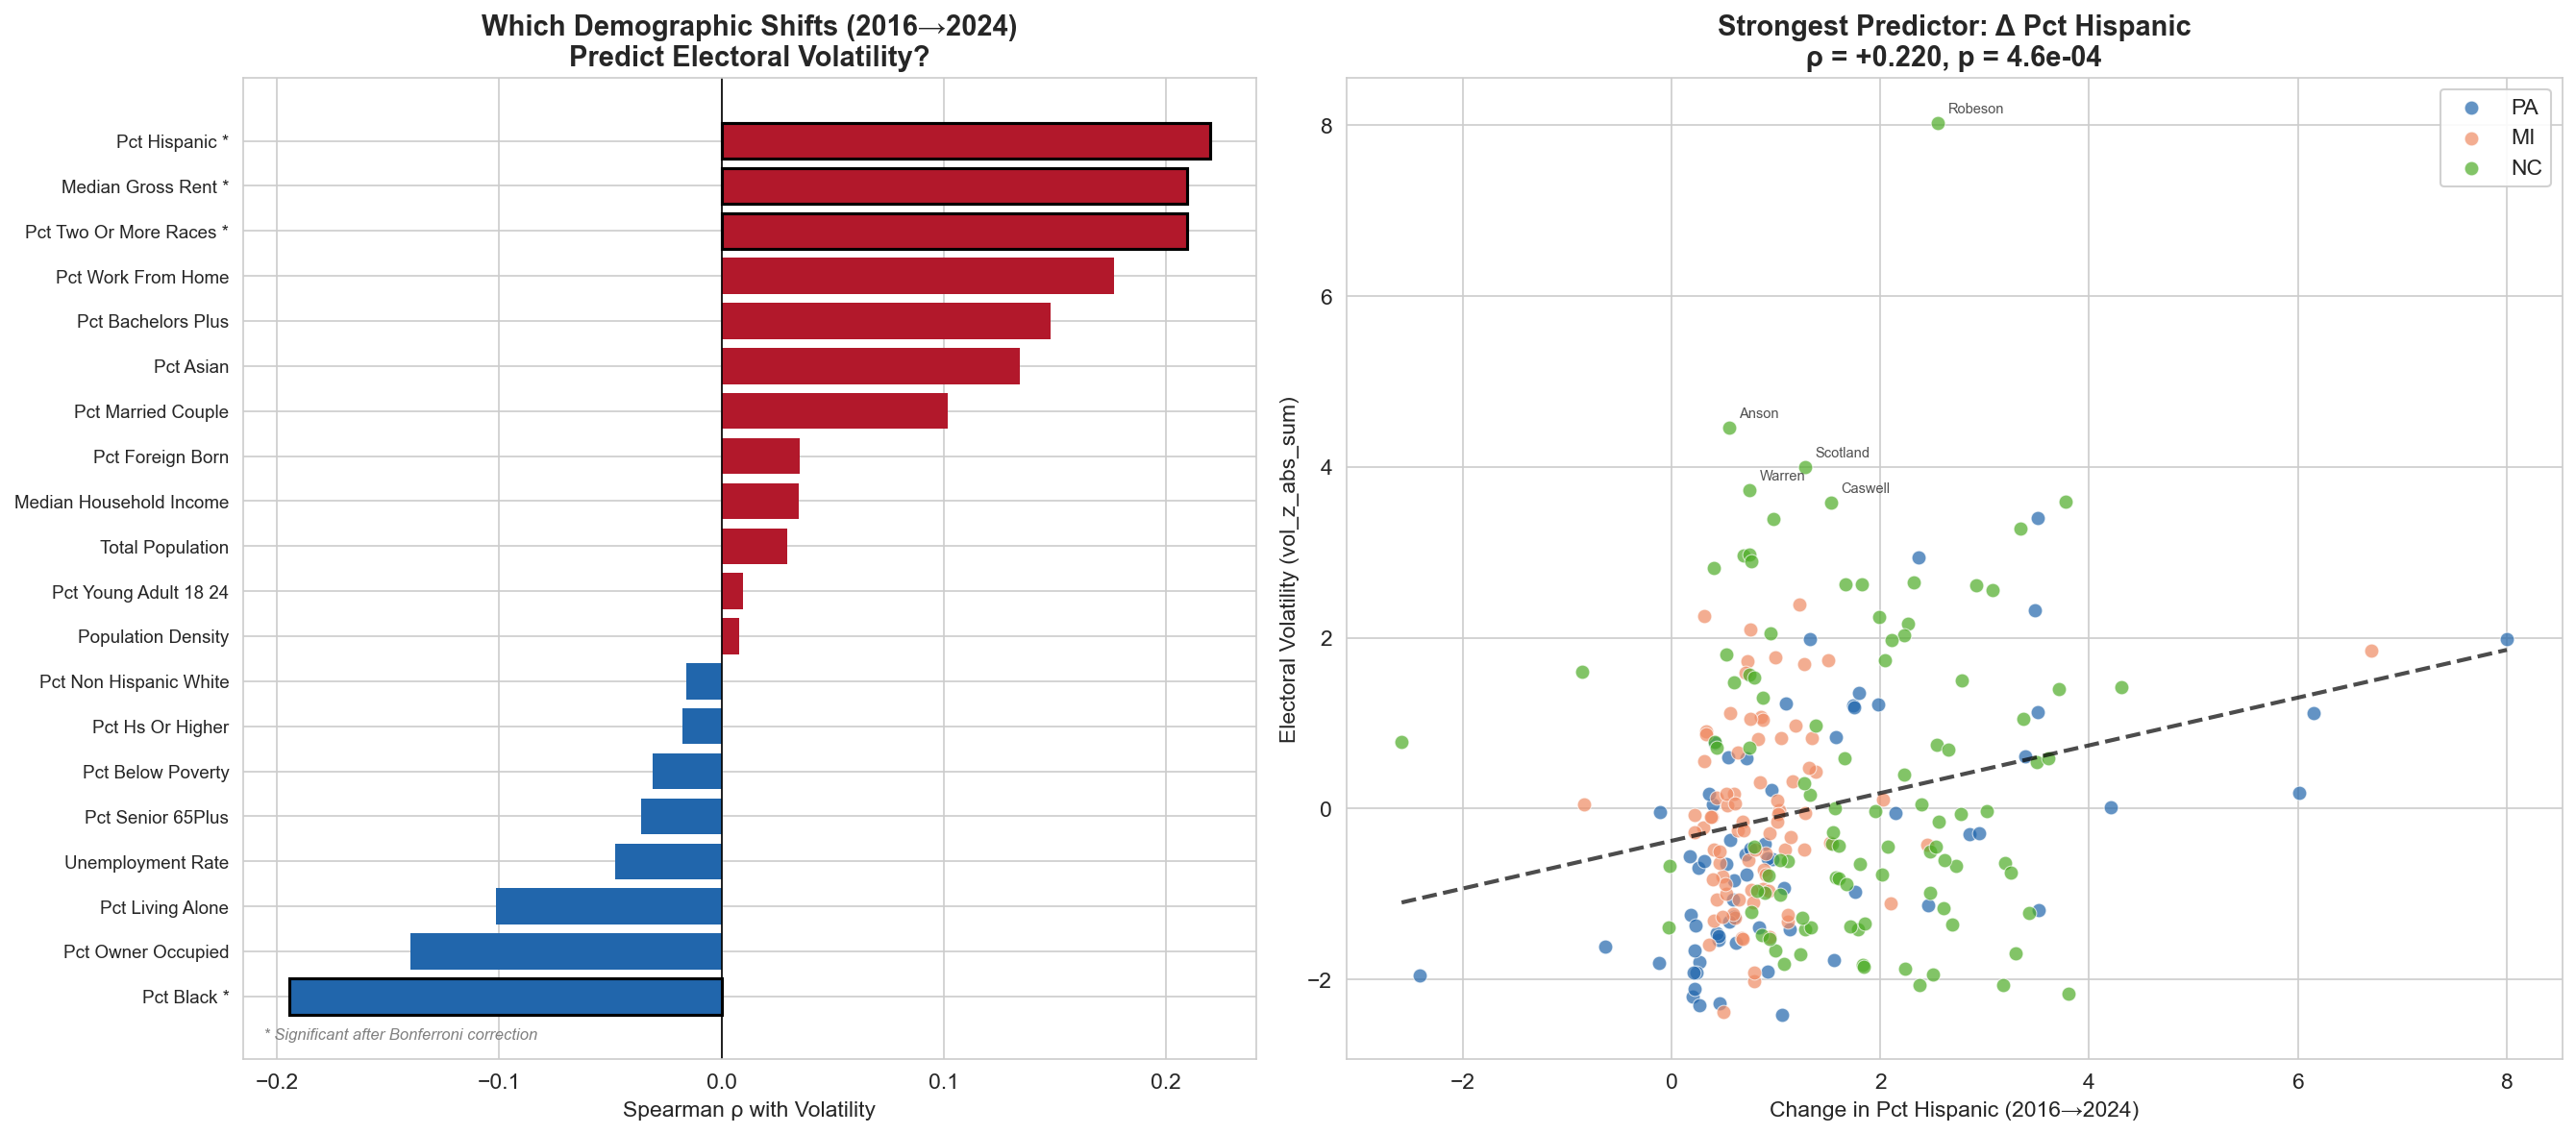


Top temporal predictor: Δ pct_hispanic (ρ=+0.220)


In [4]:
# ── Hero Figure: Demographic Change vs Volatility ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                gridspec_kw={'width_ratios': [1, 1.2]})

# Left: Correlation bar chart
plot_df = corr_df.sort_values('spearman_rho')
colors = ['#b2182b' if r > 0 else '#2166ac' for r in plot_df['spearman_rho']]
edge_colors = ['black' if s else 'none' for s in plot_df['significant']]
bars = ax1.barh(range(len(plot_df)), plot_df['spearman_rho'],
                color=colors, edgecolor=edge_colors, linewidth=1.5)

ax1.set_yticks(range(len(plot_df)))
labels = []
for _, row in plot_df.iterrows():
    name = row['feature'].replace('_', ' ').title()
    if row['significant']:
        name += ' *'
    labels.append(name)
ax1.set_yticklabels(labels, fontsize=9)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Spearman ρ with Volatility')
ax1.set_title('Which Demographic Shifts (2016→2024)\nPredict Electoral Volatility?',
              fontsize=14, fontweight='bold')
ax1.text(0.02, 0.02, '* Significant after Bonferroni correction',
         transform=ax1.transAxes, fontsize=8, style='italic', color='gray')

# Right: Scatter for strongest correlation
top_feature = corr_df.iloc[0]['feature']
top_delta_col = f'delta_{top_feature}'
top_rho = corr_df.iloc[0]['spearman_rho']
top_p = corr_df.iloc[0]['p_value']

for state in ['PA', 'MI', 'NC']:
    mask = deltas['state'] == state
    ax2.scatter(deltas.loc[mask, top_delta_col], deltas.loc[mask, 'vol_z_abs_sum'],
               c=STATE_COLORS[state], label=state, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Regression line
x_vals = deltas[top_delta_col].values
y_vals = deltas['vol_z_abs_sum'].values
mask_valid = np.isfinite(x_vals) & np.isfinite(y_vals)
z = np.polyfit(x_vals[mask_valid], y_vals[mask_valid], 1)
p_line = np.poly1d(z)
x_sorted = np.linspace(x_vals[mask_valid].min(), x_vals[mask_valid].max(), 100)
ax2.plot(x_sorted, p_line(x_sorted), 'k--', linewidth=2, alpha=0.7)

# Annotate top 5 outliers by residual
residuals = np.abs(y_vals - p_line(x_vals))
top_outliers = np.argsort(residuals)[-5:]
for idx in top_outliers:
    row = deltas.iloc[idx]
    county_name = df.loc[df['county_fips'] == row['county_fips'], 'county_name'].iloc[0]
    short_name = county_name.replace(' County', '')
    ax2.annotate(short_name, (row[top_delta_col], row['vol_z_abs_sum']),
                fontsize=7, alpha=0.8, ha='left',
                xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel(f'Change in {top_feature.replace("_", " ").title()} (2016→2024)')
ax2.set_ylabel('Electoral Volatility (vol_z_abs_sum)')
ax2.set_title(f'Strongest Predictor: Δ {top_feature.replace("_", " ").title()}\n'
              f'ρ = {top_rho:+.3f}, p = {top_p:.1e}',
              fontsize=14, fontweight='bold')
ax2.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive2_temporal_demographic_shifts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTop temporal predictor: Δ {top_feature} (ρ={top_rho:+.3f})')

---
## 2. Election-by-Election Margin Trajectories

Instead of a single volatility score, we visualize how each county's partisan margin moved across the three elections — revealing **patterns** of change (steady drift, bounceback, acceleration).

In [5]:
# ── Classify trajectory shapes using raw margins from master_dataset ──
# Pivot master to get dem_margin per year per county
margin_pivot = master.pivot_table(index='county_fips', columns='election_year',
                                   values='dem_margin').reset_index()
margin_pivot.columns = ['county_fips', 'margin_2016', 'margin_2020', 'margin_2024']

traj = df[['county_fips', 'state', 'county_name', 'vol_z_abs_sum', 'vol_binary']].merge(
    margin_pivot, on='county_fips', how='left'
)

# Compute swings in percentage points
traj['d_16_20'] = traj['margin_2020'] - traj['margin_2016']
traj['d_20_24'] = traj['margin_2024'] - traj['margin_2020']

def classify_trajectory(row):
    d1, d2 = row['d_16_20'], row['d_20_24']
    if d1 > 0 and d2 < 0:
        return 'Blue Bounceback'
    elif d1 < 0 and d2 > 0:
        return 'Red Bounceback'
    elif d1 > 0 and d2 > 0:
        return 'Steady Blue Drift'
    else:
        return 'Steady Red Drift'

traj['trajectory'] = traj.apply(classify_trajectory, axis=1)

# Summary stats
print('Trajectory Type Distribution:\n')
traj_summary = traj.groupby('trajectory').agg(
    n=('county_fips', 'count'),
    mean_vol=('vol_z_abs_sum', 'mean'),
    pct_high_vol=('vol_binary', 'mean')
).round(3)
traj_summary['pct_high_vol'] = (traj_summary['pct_high_vol'] * 100).round(1).astype(str) + '%'
print(traj_summary.to_string())

print('\nTrajectory × State:')
print(pd.crosstab(traj['trajectory'], traj['state']))
print(f'\nMargin range: {traj["margin_2024"].min():.1f} to {traj["margin_2024"].max():.1f} pp')


Trajectory Type Distribution:

                     n  mean_vol pct_high_vol
trajectory                                   
Blue Bounceback    117    -0.169        34.2%
Red Bounceback       4    -1.817         0.0%
Steady Blue Drift   35    -0.278        37.1%
Steady Red Drift    94     0.392        50.0%

Trajectory × State:
state              MI  NC  PA
trajectory                   
Blue Bounceback    49  32  36
Red Bounceback      1   2   1
Steady Blue Drift   6  17  12
Steady Red Drift   27  49  18

Margin range: -72.6 to 61.7 pp


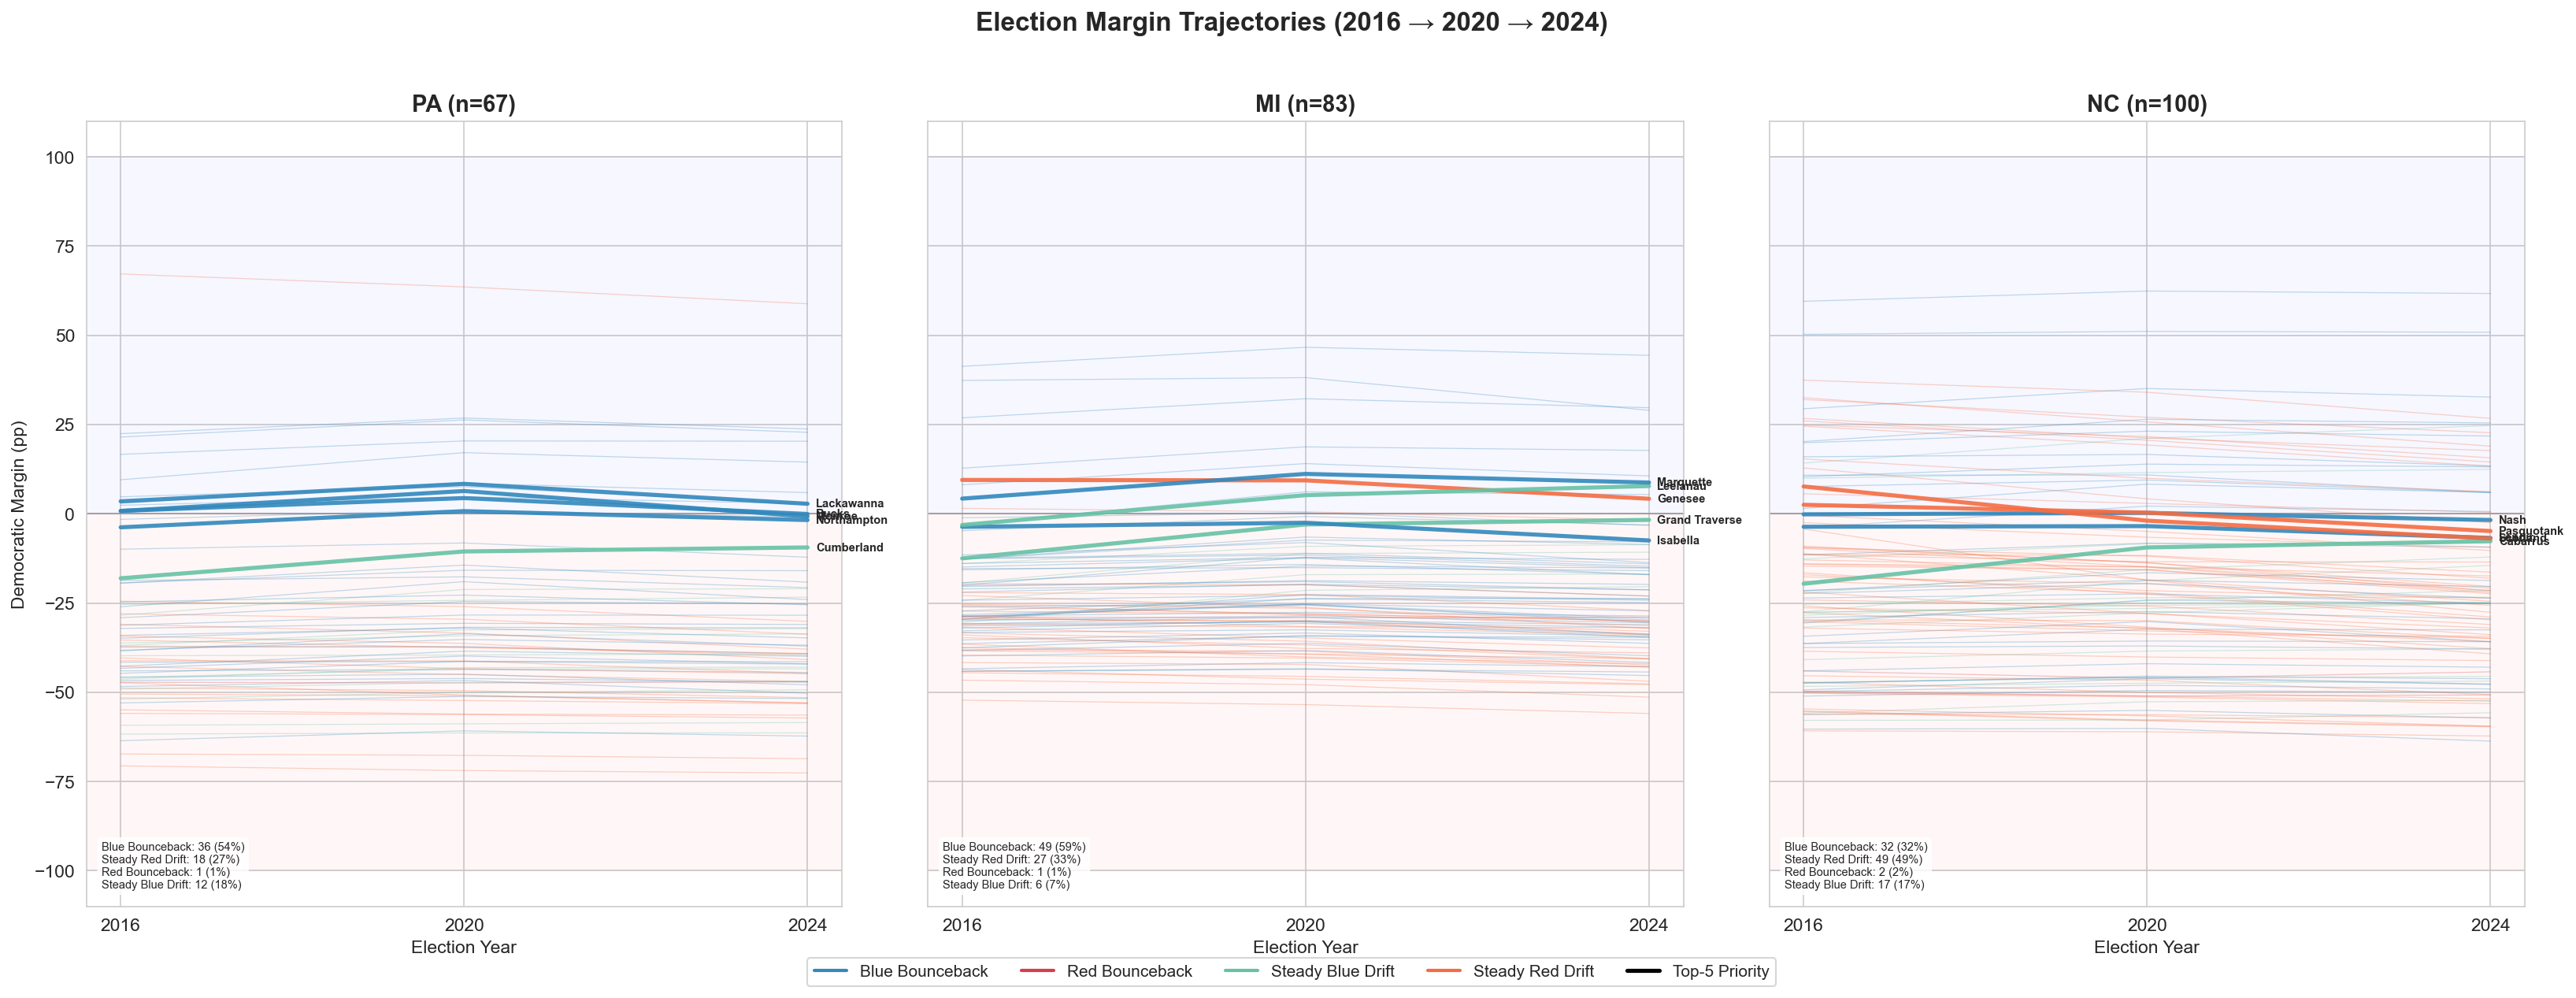

In [6]:
# ── Hero Figure: Spaghetti Trajectories by State ──
TRAJ_COLORS = {
    'Blue Bounceback': '#3288bd',
    'Red Bounceback': '#d53e4f',
    'Steady Blue Drift': '#66c2a5',
    'Steady Red Drift': '#f46d43'
}

# Get top-5 priority counties per state
if 'priority_score' in df.columns:
    top_priority = df.sort_values('priority_score', ascending=False).groupby('state').head(5)
    top_fips = set(top_priority['county_fips'])
else:
    top_fips = set()

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
years = [2016, 2020, 2024]

for ax, state in zip(axes, ['PA', 'MI', 'NC']):
    state_data = traj[traj['state'] == state]
    
    # Background: D/R divide
    ax.axhline(0, color='gray', linewidth=1, linestyle='-', alpha=0.5)
    ax.axhspan(0, 100, alpha=0.03, color='blue')
    ax.axhspan(-100, 0, alpha=0.03, color='red')
    
    # Draw all trajectories
    for _, row in state_data.iterrows():
        margins = [row['margin_2016'], row['margin_2020'], row['margin_2024']]
        is_priority = row['county_fips'] in top_fips
        color = TRAJ_COLORS[row['trajectory']]
        
        if is_priority:
            ax.plot(years, margins, color=color, linewidth=2.5, alpha=0.9, zorder=5)
            short_name = row['county_name'].replace(' County', '')
            ax.annotate(short_name, (2024, margins[-1]),
                       fontsize=7, fontweight='bold',
                       xytext=(5, 0), textcoords='offset points',
                       ha='left', va='center', zorder=6)
        else:
            ax.plot(years, margins, color=color, linewidth=0.6, alpha=0.3)
    
    ax.set_title(f'{state} (n={len(state_data)})', fontsize=14, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xlabel('Election Year')
    
    # Trajectory type counts
    counts = state_data['trajectory'].value_counts()
    text_lines = []
    for t_type in ['Blue Bounceback', 'Steady Red Drift', 'Red Bounceback', 'Steady Blue Drift']:
        n = counts.get(t_type, 0)
        pct = n / len(state_data) * 100
        text_lines.append(f'{t_type}: {n} ({pct:.0f}%)')
    ax.text(0.02, 0.02, '\n'.join(text_lines), transform=ax.transAxes,
            fontsize=7, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Democratic Margin (pp)')

# Shared legend
legend_elements = [Line2D([0], [0], color=TRAJ_COLORS[t], linewidth=2, label=t)
                   for t in ['Blue Bounceback', 'Red Bounceback', 'Steady Blue Drift', 'Steady Red Drift']]
legend_elements.append(Line2D([0], [0], color='black', linewidth=2.5, label='Top-5 Priority'))
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Election Margin Trajectories (2016 → 2020 → 2024)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive2_margin_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Partial Dependence Analysis — True Shape of Feature Effects

SHAP shows each feature's contribution *per county*. Partial Dependence Plots (PDPs) show the **marginal effect** averaged across all counties — revealing the true functional form (linear, threshold, U-shaped).

In [7]:
# ── Train binary RF for PDP analysis ──
rf_pdp = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_pdp.fit(X, y_binary)

# Top 6 features for PDP
top6_features = ['race_entropy_norm', 'log_median_gross_rent', 'pct_below_poverty',
                 'pct_married_couple', 'pct_bachelors_plus', 'log_population_density']
top6_idx = [feature_names.index(f) for f in top6_features]

print(f'RF trained on {X.shape[0]} samples, {X.shape[1]} features.')
print(f'PDP features: {top6_features}')

RF trained on 250 samples, 28 features.
PDP features: ['race_entropy_norm', 'log_median_gross_rent', 'pct_below_poverty', 'pct_married_couple', 'pct_bachelors_plus', 'log_population_density']


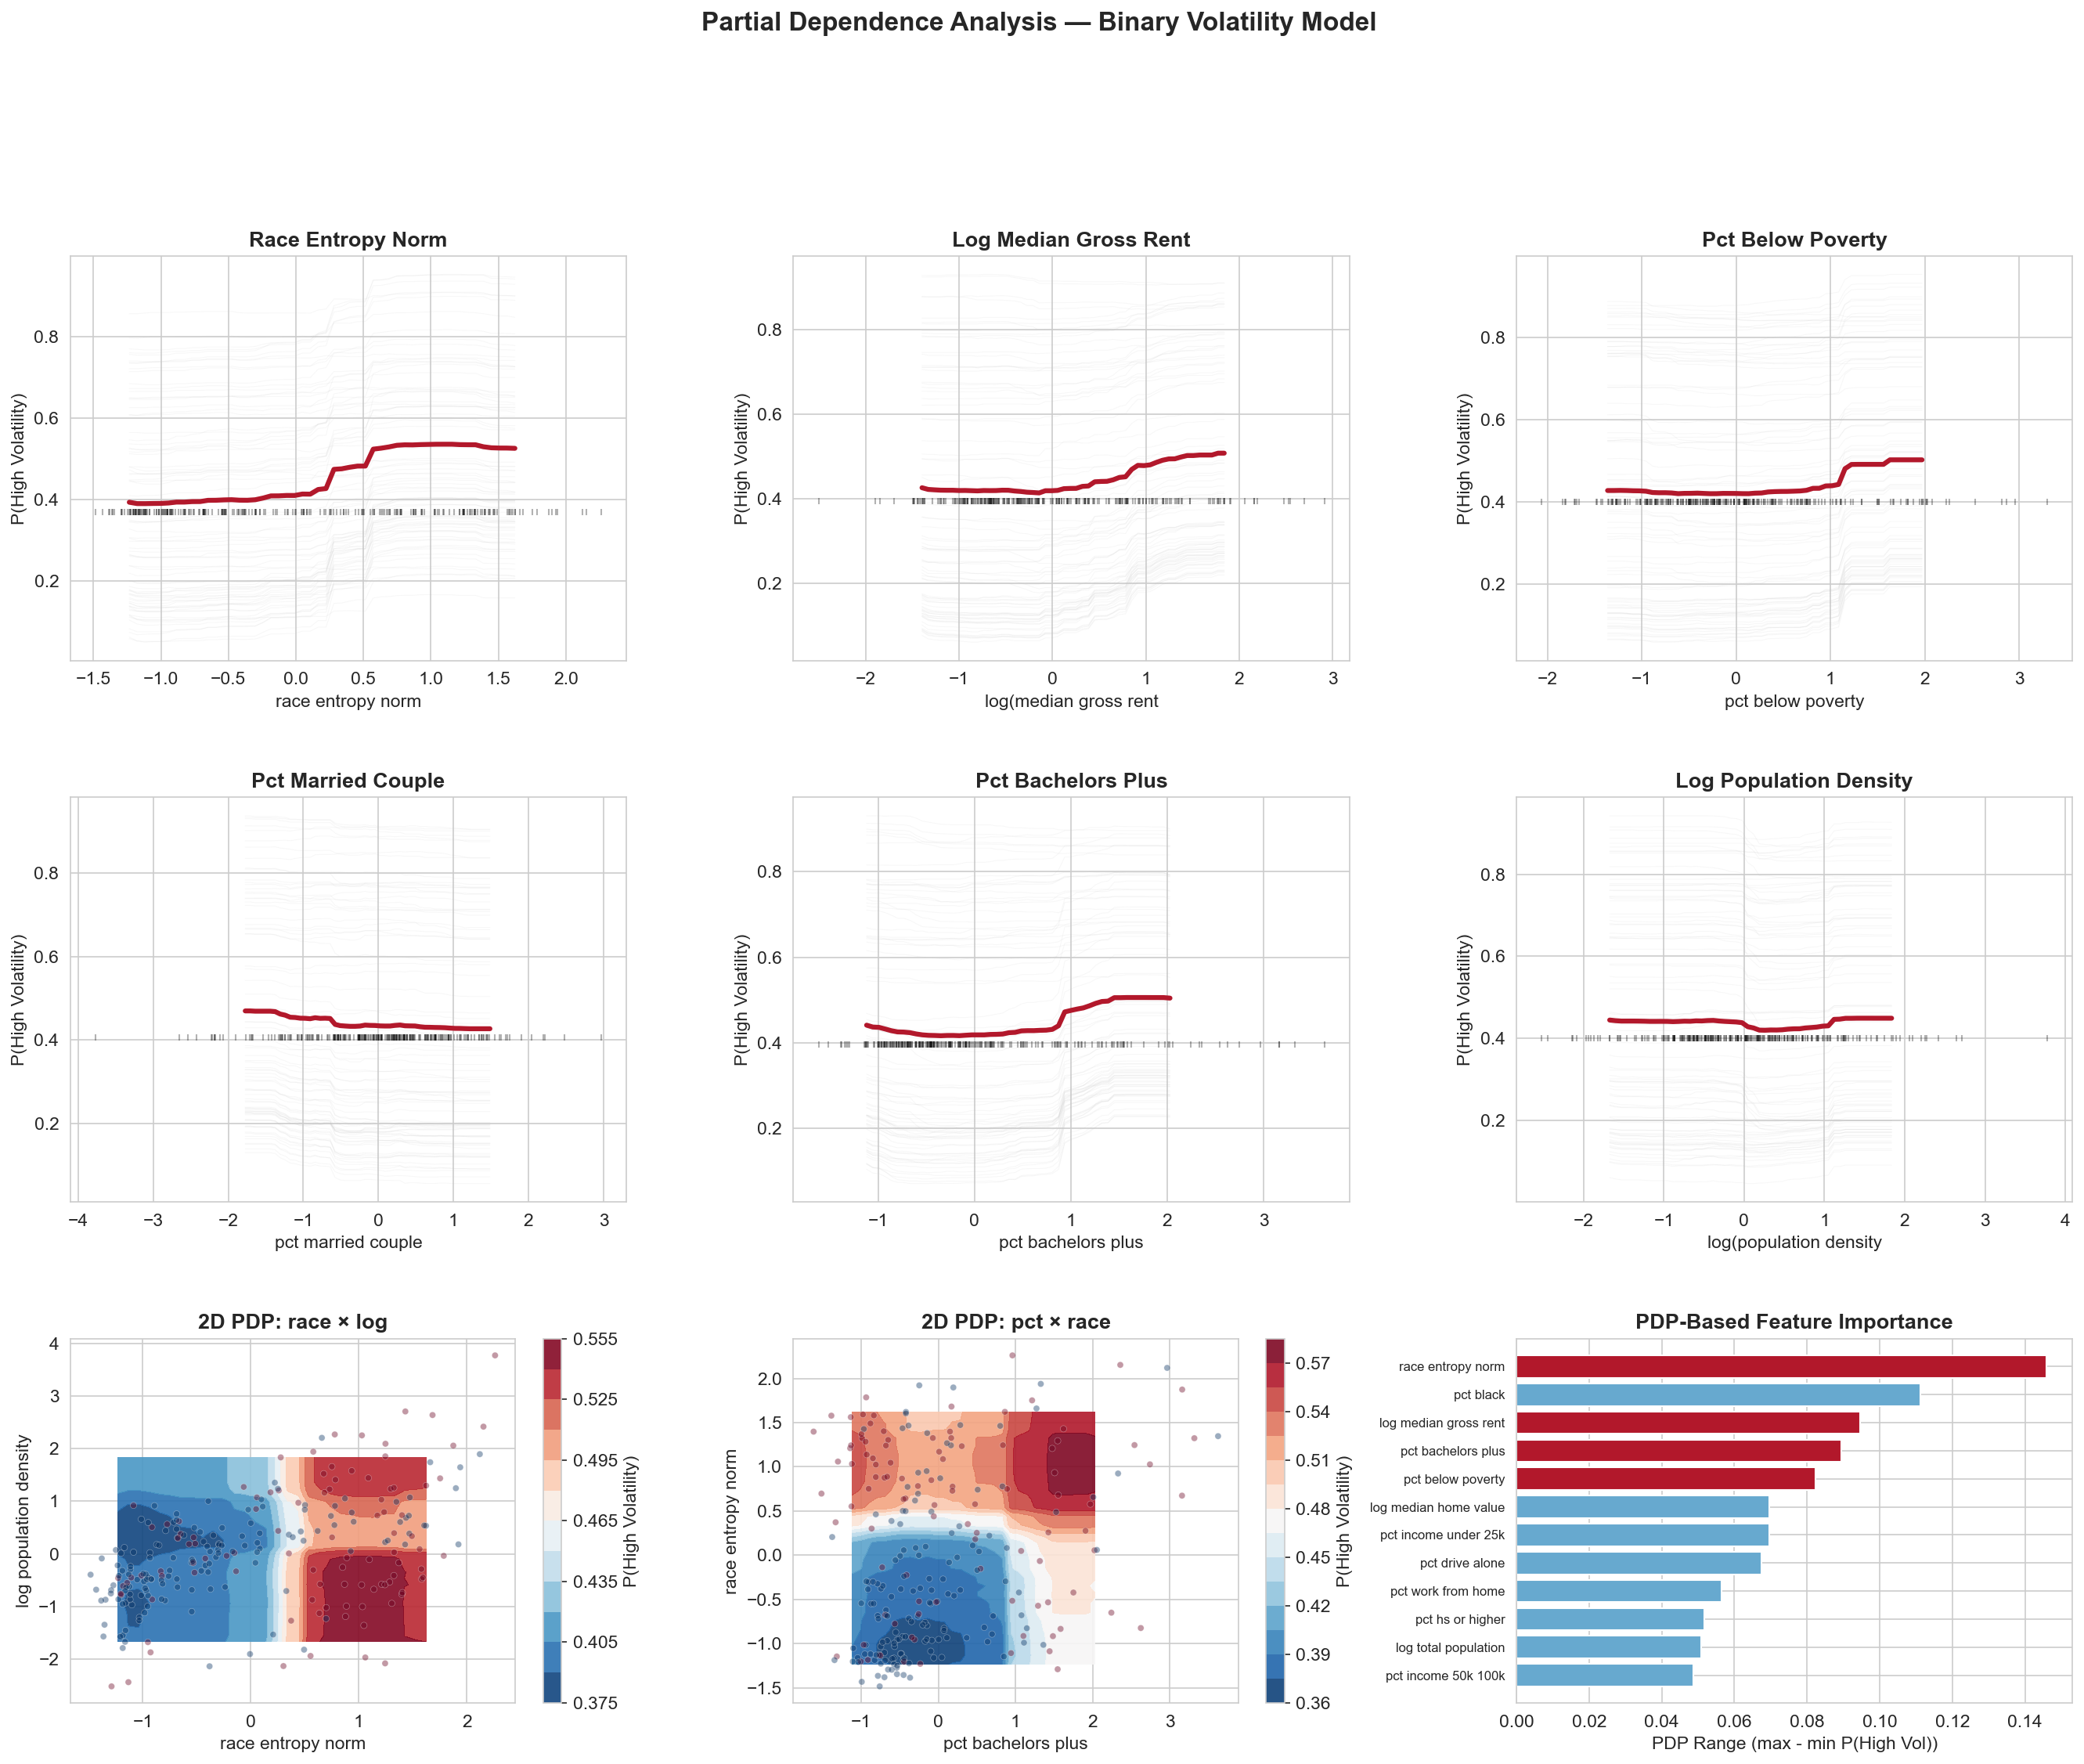

In [8]:
# ── Hero Figure: Partial Dependence with ICE lines ──
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3,
                       height_ratios=[1, 1, 0.9])

# Top 2 rows: 6 individual PDPs with ICE
for i, (feat, feat_idx) in enumerate(zip(top6_features, top6_idx)):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])
    
    # Compute PDP + ICE
    pd_result = partial_dependence(
        rf_pdp, X, features=[feat_idx],
        kind='both', grid_resolution=50
    )
    
    grid_values = pd_result['grid_values'][0]
    avg_pred = pd_result['average'][0]
    
    # ICE lines (subsample for readability)
    if 'individual' in pd_result:
        ice = pd_result['individual'][0]
        n_ice = min(80, ice.shape[0])
        indices = np.random.choice(ice.shape[0], n_ice, replace=False)
        for idx in indices:
            ax.plot(grid_values, ice[idx], color='#cccccc', alpha=0.15, linewidth=0.5)
    
    # PDP curve (bold)
    ax.plot(grid_values, avg_pred, color='#b2182b', linewidth=3, zorder=10)
    
    # Rug plot
    feature_vals = X[:, feat_idx]
    ax.plot(feature_vals, np.full_like(feature_vals, avg_pred.min() - 0.02),
            '|', color='black', alpha=0.3, markersize=4)
    
    ax.set_xlabel(feat.replace('_', ' ').replace('log ', 'log(').replace('norm', 'norm)') 
                  if 'log' in feat else feat.replace('_', ' '))
    ax.set_ylabel('P(High Volatility)')
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')

# Bottom row: 2D PDP contour plots for top 2 interactions
interactions_2d = [
    ('race_entropy_norm', 'log_population_density'),
    ('pct_bachelors_plus', 'race_entropy_norm')
]

for j, (f1, f2) in enumerate(interactions_2d):
    ax = fig.add_subplot(gs[2, j])
    f1_idx = feature_names.index(f1)
    f2_idx = feature_names.index(f2)
    
    pd_2d = partial_dependence(
        rf_pdp, X, features=[(f1_idx, f2_idx)],
        kind='average', grid_resolution=30
    )
    
    XX, YY = np.meshgrid(pd_2d['grid_values'][0], pd_2d['grid_values'][1])
    ZZ = pd_2d['average'][0].T
    
    contour = ax.contourf(XX, YY, ZZ, levels=15, cmap='RdBu_r', alpha=0.9)
    plt.colorbar(contour, ax=ax, label='P(High Volatility)')
    
    # Overlay data points
    ax.scatter(X[:, f1_idx], X[:, f2_idx], c=y_binary, cmap='RdBu_r',
              s=15, alpha=0.4, edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel(f1.replace('_', ' '))
    ax.set_ylabel(f2.replace('_', ' '))
    ax.set_title(f'2D PDP: {f1.split("_")[0]} × {f2.split("_")[0]}', fontweight='bold')

# Bottom-right: PDP-based importance
ax_imp = fig.add_subplot(gs[2, 2])
pdp_importance = []
for feat, feat_idx in zip(feature_names, range(len(feature_names))):
    pd_1d = partial_dependence(rf_pdp, X, features=[feat_idx], kind='average', grid_resolution=30)
    spread = pd_1d['average'][0].max() - pd_1d['average'][0].min()
    pdp_importance.append((feat, spread))

pdp_imp_df = pd.DataFrame(pdp_importance, columns=['feature', 'pdp_range']).sort_values('pdp_range', ascending=True)
top12 = pdp_imp_df.tail(12)
colors_imp = ['#b2182b' if f in top6_features else '#67a9cf' for f in top12['feature']]
ax_imp.barh(range(len(top12)), top12['pdp_range'], color=colors_imp)
ax_imp.set_yticks(range(len(top12)))
ax_imp.set_yticklabels([f.replace('_', ' ') for f in top12['feature']], fontsize=8)
ax_imp.set_xlabel('PDP Range (max - min P(High Vol))')
ax_imp.set_title('PDP-Based Feature Importance', fontweight='bold')

fig.suptitle('Partial Dependence Analysis — Binary Volatility Model',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig(f'{FIG_DIR}/deepdive2_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Model Robustness — Bootstrap CIs & Feature Group Ablation

How stable are our performance claims? Bootstrap the metrics for confidence intervals, then systematically remove feature groups to measure each group's true contribution.

In [9]:
# ── Bootstrap Confidence Intervals ──
def bootstrap_cv_metrics(X, y, model_class, model_params, n_boot=200, n_folds=5):
    """Bootstrap resampling with stratified CV inside each resample."""
    metrics = {'f1': [], 'auc': [], 'acc': []}
    
    for i in range(n_boot):
        # Resample with replacement
        idx = resample(np.arange(len(y)), stratify=y, random_state=RANDOM_STATE + i)
        X_boot, y_boot = X[idx], y[idx]
        
        # CV on resample
        cv = StratifiedKFold(n_folds, shuffle=True, random_state=RANDOM_STATE)
        preds = cross_val_predict(model_class(**model_params), X_boot, y_boot, cv=cv)
        proba = cross_val_predict(model_class(**model_params), X_boot, y_boot, cv=cv, method='predict_proba')[:, 1]
        
        metrics['f1'].append(f1_score(y_boot, preds))
        metrics['auc'].append(roc_auc_score(y_boot, proba))
        metrics['acc'].append(accuracy_score(y_boot, preds))
    
    return {k: (np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5))
            for k, v in metrics.items()}

print('Running bootstrap (200 iterations × 5-fold CV)...')
print('This may take 2-3 minutes.\n')

# RF bootstrap
rf_params = dict(n_estimators=300, max_depth=8, min_samples_leaf=5,
                 max_features='sqrt', class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)
rf_ci = bootstrap_cv_metrics(X, y_binary, RandomForestClassifier, rf_params, n_boot=200)

# XGBoost bootstrap
xgb_params = dict(n_estimators=300, max_depth=4, learning_rate=0.1,
                  subsample=0.8, random_state=RANDOM_STATE, verbosity=0,
                  eval_metric='logloss', use_label_encoder=False)
xgb_ci = bootstrap_cv_metrics(X, y_binary, xgb.XGBClassifier, xgb_params, n_boot=200)

print('Model            F1 [95% CI]              AUC [95% CI]             Accuracy [95% CI]')
print('-' * 90)
for name, ci in [('Random Forest', rf_ci), ('XGBoost', xgb_ci)]:
    f1_str = f"{ci['f1'][0]:.3f} [{ci['f1'][1]:.3f}, {ci['f1'][2]:.3f}]"
    auc_str = f"{ci['auc'][0]:.3f} [{ci['auc'][1]:.3f}, {ci['auc'][2]:.3f}]"
    acc_str = f"{ci['acc'][0]:.3f} [{ci['acc'][1]:.3f}, {ci['acc'][2]:.3f}]"
    print(f'{name:16s} {f1_str:24s} {auc_str:24s} {acc_str}')

Running bootstrap (200 iterations × 5-fold CV)...
This may take 2-3 minutes.

Model            F1 [95% CI]              AUC [95% CI]             Accuracy [95% CI]
------------------------------------------------------------------------------------------
Random Forest    0.818 [0.764, 0.872]     0.918 [0.882, 0.946]     0.856 [0.816, 0.900]
XGBoost          0.845 [0.789, 0.899]     0.932 [0.894, 0.966]     0.880 [0.840, 0.920]


In [10]:
# ── Feature Group Ablation ──
feature_groups = {
    'Race / Ethnicity': ['pct_black', 'pct_asian', 'pct_two_or_more_races',
                         'pct_hispanic', 'race_entropy_norm', 'pct_foreign_born'],
    'Economic': ['pct_below_poverty', 'pct_income_under_25k', 'pct_income_50k_100k',
                 'unemployment_rate', 'log_median_household_income'],
    'Housing': ['pct_owner_occupied', 'log_median_gross_rent', 'log_median_home_value'],
    'Education': ['pct_hs_or_higher', 'pct_bachelors_plus'],
    'Household / Age': ['pct_family_households', 'pct_married_couple', 'pct_living_alone',
                        'pct_senior_65plus', 'pct_young_adult_18_24', 'median_age'],
    'Urbanization': ['log_total_population', 'log_population_density',
                     'pct_drive_alone', 'pct_carpool', 'pct_public_transit',
                     'pct_work_from_home']
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rf_base = RandomForestClassifier(**rf_params)

# Baseline: all features
base_preds = cross_val_predict(rf_base, X, y_binary, cv=cv)
baseline_f1 = f1_score(y_binary, base_preds)

ablation_results = []
for group_name, group_feats in feature_groups.items():
    # Filter to features that actually exist in our feature set
    group_idx = [i for i, f in enumerate(feature_names) if f in group_feats]
    remaining_idx = [i for i in range(len(feature_names)) if i not in group_idx]
    only_idx = group_idx
    
    if len(group_idx) == 0:
        continue
    
    # Without this group
    X_without = X[:, remaining_idx]
    preds_without = cross_val_predict(
        RandomForestClassifier(**rf_params), X_without, y_binary, cv=cv)
    f1_without = f1_score(y_binary, preds_without)
    
    # Only this group
    X_only = X[:, only_idx]
    preds_only = cross_val_predict(
        RandomForestClassifier(**rf_params), X_only, y_binary, cv=cv)
    f1_only = f1_score(y_binary, preds_only)
    
    ablation_results.append({
        'group': group_name,
        'n_features': len(group_idx),
        'f1_without': f1_without,
        'f1_drop': baseline_f1 - f1_without,
        'f1_only': f1_only
    })

abl_df = pd.DataFrame(ablation_results).sort_values('f1_drop', ascending=False)
print(f'Baseline F1 (all features): {baseline_f1:.3f}\n')
print(f'{"Group":25s} {"n":>3s} {"F1 without":>11s} {"F1 drop":>8s} {"F1 only":>8s}')
print('-' * 60)
for _, row in abl_df.iterrows():
    print(f"{row['group']:25s} {row['n_features']:3d} {row['f1_without']:11.3f} {row['f1_drop']:+8.3f} {row['f1_only']:8.3f}")

Baseline F1 (all features): 0.718

Group                       n  F1 without  F1 drop  F1 only
------------------------------------------------------------
Race / Ethnicity            6       0.626   +0.092    0.619
Urbanization                6       0.684   +0.034    0.583
Education                   2       0.708   +0.010    0.583
Housing                     3       0.712   +0.006    0.612
Economic                    5       0.722   -0.004    0.570
Household / Age             6       0.728   -0.010    0.471


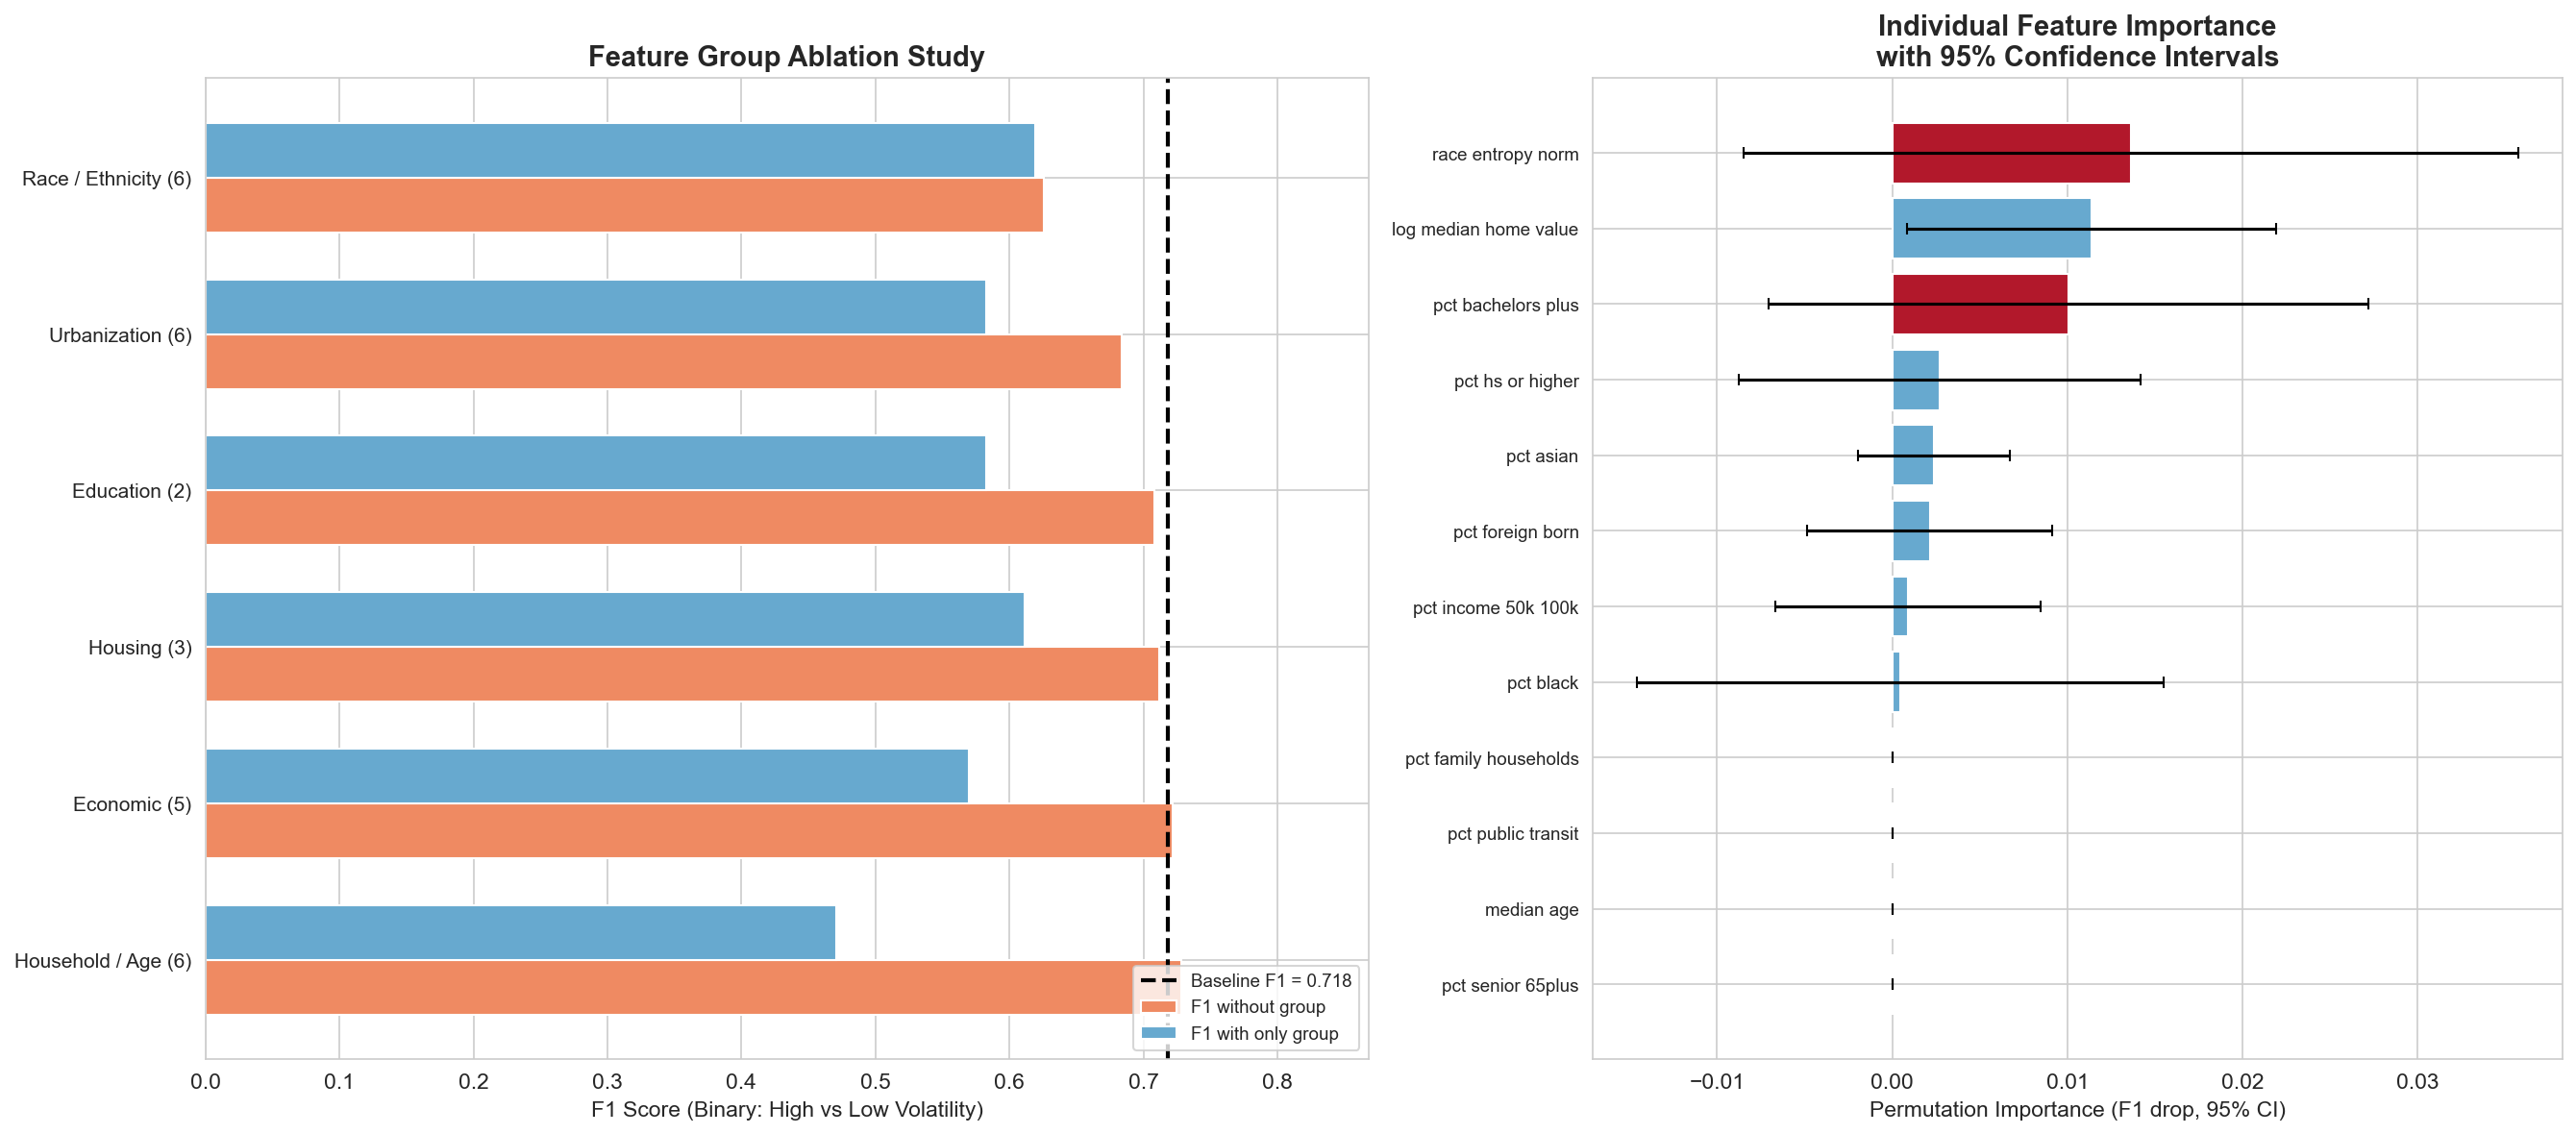

In [11]:
# ── Hero Figure: Feature Ablation + Bootstrap CI ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# Left: Ablation grouped bar chart
abl_sorted = abl_df.sort_values('f1_drop', ascending=True)
y_pos = np.arange(len(abl_sorted))
bar_height = 0.35

ax1.barh(y_pos - bar_height/2, abl_sorted['f1_without'], bar_height,
         label='F1 without group', color='#ef8a62', edgecolor='white')
ax1.barh(y_pos + bar_height/2, abl_sorted['f1_only'], bar_height,
         label='F1 with only group', color='#67a9cf', edgecolor='white')
ax1.axvline(baseline_f1, color='black', linestyle='--', linewidth=2,
            label=f'Baseline F1 = {baseline_f1:.3f}')

ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"{row['group']} ({row['n_features']})"
                      for _, row in abl_sorted.iterrows()], fontsize=10)
ax1.set_xlabel('F1 Score (Binary: High vs Low Volatility)')
ax1.set_title('Feature Group Ablation Study', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.set_xlim(0, baseline_f1 + 0.15)

# Right: Permutation importance with bootstrap CIs
from sklearn.inspection import permutation_importance
perm_imp = permutation_importance(rf_pdp, X, y_binary,
                                   n_repeats=50, random_state=RANDOM_STATE,
                                   scoring='f1', n_jobs=-1)

imp_df = pd.DataFrame({
    'feature': feature_names,
    'mean': perm_imp.importances_mean,
    'std': perm_imp.importances_std
}).sort_values('mean', ascending=True).tail(12)

colors_perm = ['#b2182b' if f in top6_features else '#67a9cf' for f in imp_df['feature']]
ax2.barh(range(len(imp_df)), imp_df['mean'], xerr=imp_df['std'] * 1.96,
         color=colors_perm, capsize=3, edgecolor='white')
ax2.set_yticks(range(len(imp_df)))
ax2.set_yticklabels([f.replace('_', ' ') for f in imp_df['feature']], fontsize=9)
ax2.set_xlabel('Permutation Importance (F1 drop, 95% CI)')
ax2.set_title('Individual Feature Importance\nwith 95% Confidence Intervals',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive2_feature_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Ensemble Stacking — Can We Beat 0.708 F1?

The prior notebooks tested models individually. Here we combine them via **stacking** and **voting** to probe the performance ceiling.

In [12]:
# ── Ensemble models ──
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# Base learners
rf_est = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_est = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE, verbosity=0,
    eval_metric='logloss', use_label_encoder=False
)
svm_est = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, random_state=RANDOM_STATE
)

# Individual models
models = {
    'Random Forest': rf_est,
    'XGBoost': xgb_est,
    'SVM (RBF)': svm_est,
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
}

# Ensembles
models['Soft Voting'] = VotingClassifier(
    estimators=[('rf', rf_est), ('xgb', xgb_est), ('svm', svm_est)],
    voting='soft'
)
models['Stacking (LR meta)'] = StackingClassifier(
    estimators=[('rf', rf_est), ('xgb', xgb_est), ('svm', svm_est)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=3, passthrough=False
)

# Evaluate all
results = {}
print(f'{"Model":25s} {"Accuracy":>8s} {"F1":>8s} {"AUC":>8s}')
print('-' * 55)

for name, model in models.items():
    preds = cross_val_predict(model, X, y_binary, cv=cv)
    proba = cross_val_predict(model, X, y_binary, cv=cv, method='predict_proba')[:, 1]
    
    acc = accuracy_score(y_binary, preds)
    f1 = f1_score(y_binary, preds)
    auc = roc_auc_score(y_binary, proba)
    
    results[name] = {'acc': acc, 'f1': f1, 'auc': auc, 'proba': proba, 'preds': preds}
    marker = ' ◄' if f1 == max(r['f1'] for r in results.values()) else ''
    print(f'{name:25s} {acc:8.3f} {f1:8.3f} {auc:8.3f}{marker}')

best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nBest model: {best_name} (F1={results[best_name]["f1"]:.3f})')

Model                     Accuracy       F1      AUC
-------------------------------------------------------
Random Forest                0.780    0.718    0.828 ◄
XGBoost                      0.748    0.667    0.803
SVM (RBF)                    0.760    0.663    0.819
Logistic Regression          0.680    0.604    0.745
Soft Voting                  0.768    0.691    0.826
Stacking (LR meta)           0.760    0.647    0.816

Best model: Random Forest (F1=0.718)


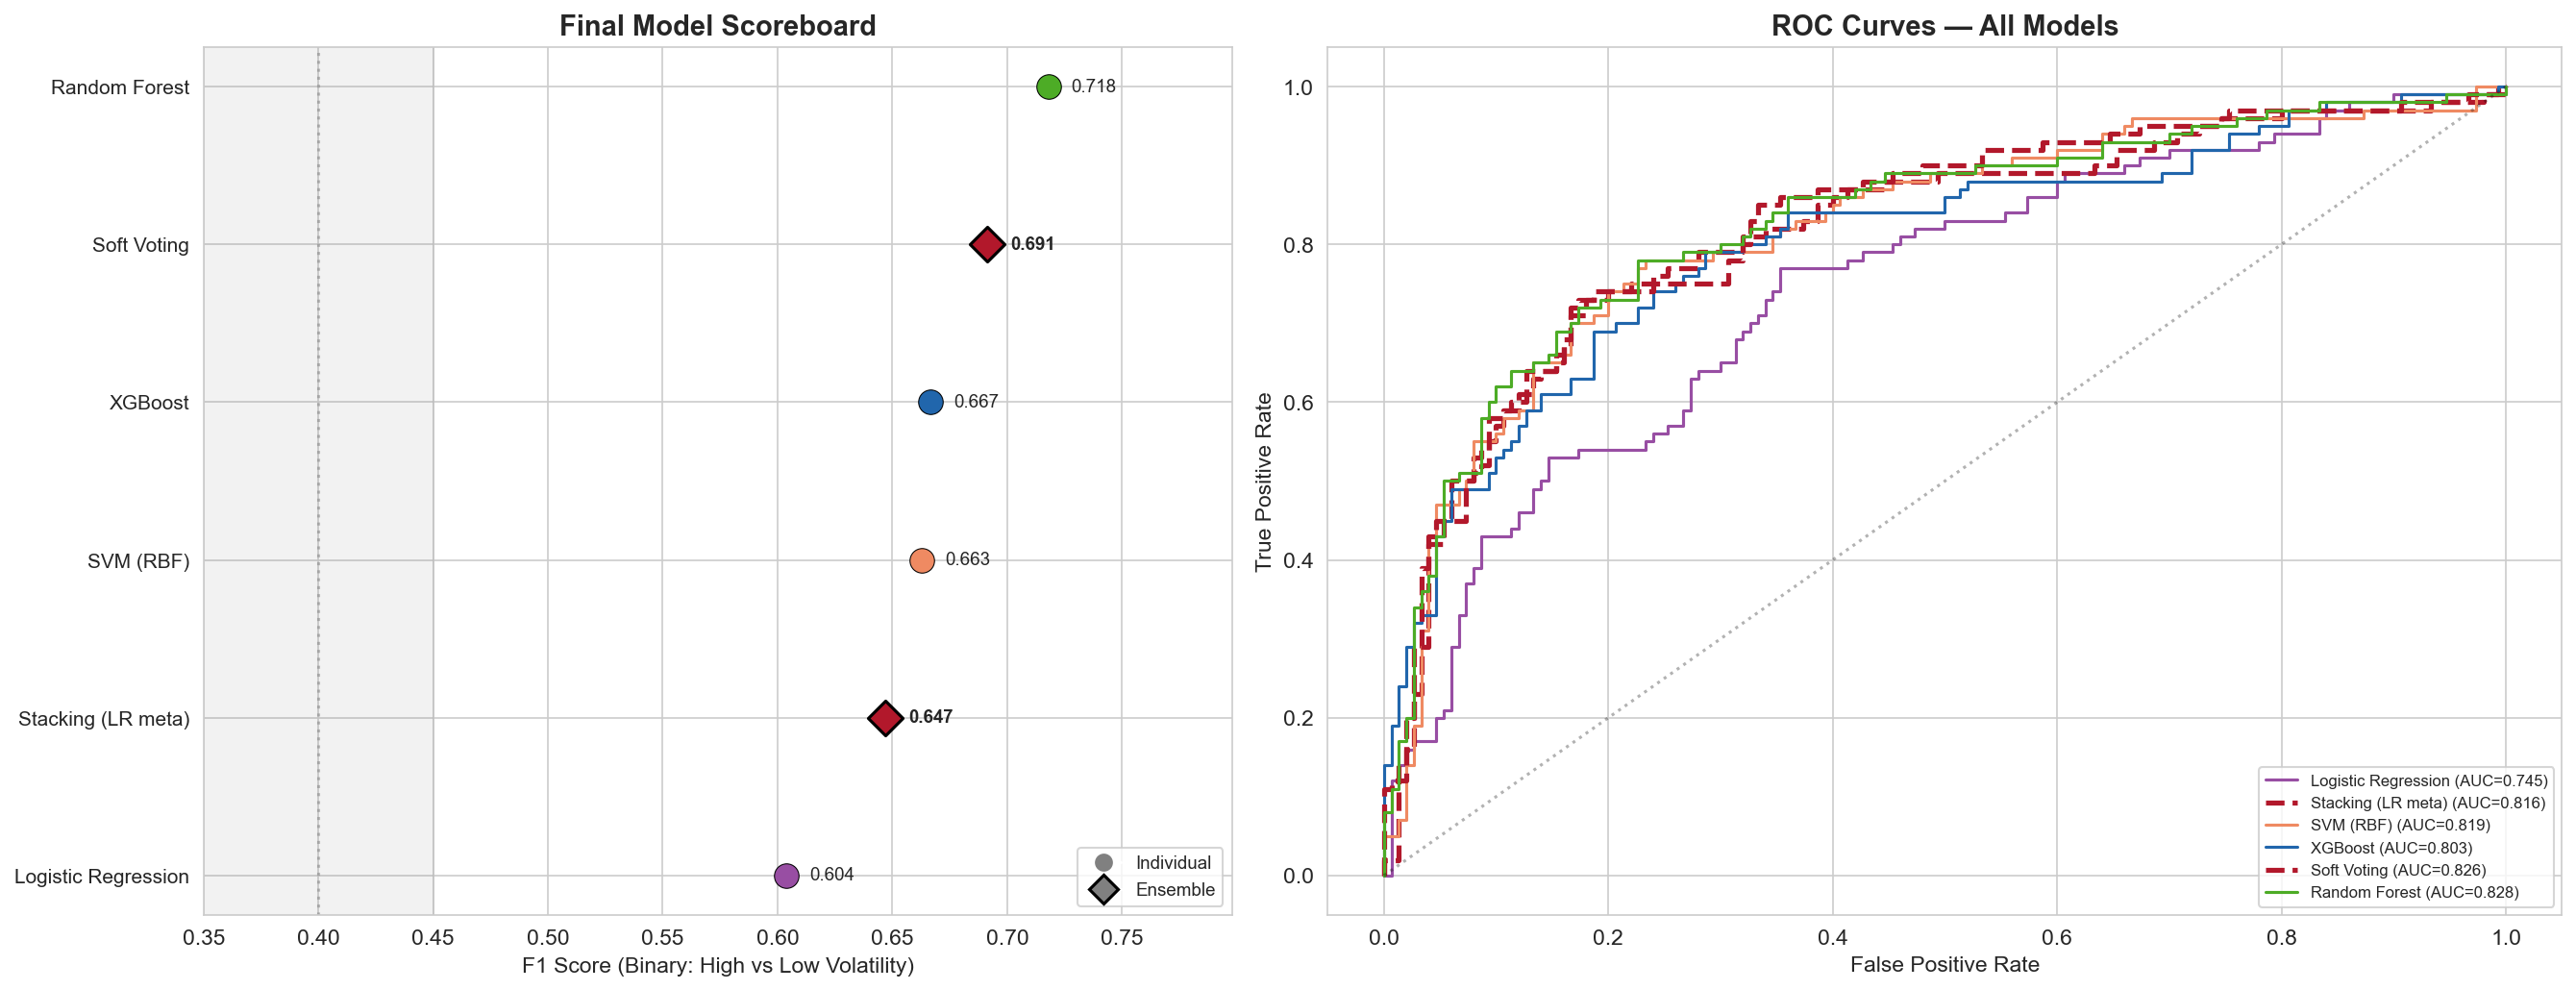

In [13]:
# ── Hero Figure: Final Model Scoreboard + ROC ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7),
                                gridspec_kw={'width_ratios': [1, 1.2]})

# Left: Dot plot with F1 scores
model_order = sorted(results.keys(), key=lambda k: results[k]['f1'])
y_pos = range(len(model_order))

family_colors = {
    'Random Forest': '#4dac26', 'XGBoost': '#2166ac', 'SVM (RBF)': '#ef8a62',
    'Logistic Regression': '#984ea3', 'Soft Voting': '#b2182b', 'Stacking (LR meta)': '#b2182b'
}

for i, name in enumerate(model_order):
    color = family_colors.get(name, 'gray')
    is_ensemble = name in ['Soft Voting', 'Stacking (LR meta)']
    marker = 'D' if is_ensemble else 'o'
    ax1.scatter(results[name]['f1'], i, s=150, c=color, marker=marker,
               edgecolors='black', linewidth=1.5 if is_ensemble else 0.5, zorder=5)
    ax1.text(results[name]['f1'] + 0.01, i, f"{results[name]['f1']:.3f}",
            va='center', fontsize=9, fontweight='bold' if is_ensemble else 'normal')

# Random baseline zone
ax1.axvspan(0.35, 0.45, alpha=0.1, color='gray', label='Near-random zone')
ax1.axvline(0.4, color='gray', linestyle=':', alpha=0.5)

ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(model_order, fontsize=10)
ax1.set_xlabel('F1 Score (Binary: High vs Low Volatility)', fontsize=11)
ax1.set_title('Final Model Scoreboard', fontsize=14, fontweight='bold')
ax1.set_xlim(0.35, max(r['f1'] for r in results.values()) + 0.08)

# Legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Individual'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', markeredgewidth=1.5, label='Ensemble'),
]
ax1.legend(handles=legend_elems, loc='lower right', fontsize=9)

# Right: ROC curves for all models
for name in model_order:
    fpr, tpr, _ = roc_curve(y_binary, results[name]['proba'])
    color = family_colors.get(name, 'gray')
    is_ensemble = name in ['Soft Voting', 'Stacking (LR meta)']
    ax2.plot(fpr, tpr, color=color, linewidth=2.5 if is_ensemble else 1.5,
            linestyle='-' if not is_ensemble else '--',
            label=f"{name} (AUC={results[name]['auc']:.3f})")

ax2.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive2_model_scoreboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. The Diversity Threshold — Precise Estimation

The prior analysis established that diversity is the "switch" (3× high-volatility rate above median). Here we **precisely estimate** the threshold value and its confidence interval.

In [14]:
# ── Threshold estimation via maximum-separation search + bootstrap ──

# We need raw (unscaled) race_entropy_norm for interpretability
# Get it from master_dataset for 2024
master_scaled = pd.read_csv(f'{BASE}/master_dataset_scaled.csv', dtype={'county_fips': str})
master_scaled['county_fips'] = master_scaled['county_fips'].str.zfill(5)
entropy_raw = master_scaled[master_scaled['election_year'] == 2024][['county_fips', 'race_entropy_norm']].copy()
entropy_raw.columns = ['county_fips', 'entropy_raw']

thresh_df = df[['county_fips', 'vol_binary', 'vol_z_abs_sum']].merge(entropy_raw, on='county_fips')

def find_optimal_threshold(data_df, entropy_col='entropy_raw', target_col='vol_binary'):
    """Find the entropy threshold that maximizes separation in high-vol rate."""
    vals = data_df[entropy_col].sort_values()
    candidates = np.linspace(vals.quantile(0.10), vals.quantile(0.90), 200)
    
    best_diff, best_t = 0, None
    for t in candidates:
        above = data_df.loc[data_df[entropy_col] >= t, target_col].mean()
        below = data_df.loc[data_df[entropy_col] < t, target_col].mean()
        diff = above - below
        if diff > best_diff:
            best_diff = diff
            best_t = t
    return best_t

# Point estimate
optimal_t = find_optimal_threshold(thresh_df)

# Bootstrap CI
n_boot = 1000
boot_thresholds = []
for i in range(n_boot):
    boot_sample = resample(thresh_df, stratify=thresh_df['vol_binary'], random_state=RANDOM_STATE + i)
    boot_t = find_optimal_threshold(boot_sample)
    boot_thresholds.append(boot_t)

ci_low, ci_high = np.percentile(boot_thresholds, [2.5, 97.5])

# Odds ratio at optimal threshold
above_rate = thresh_df.loc[thresh_df['entropy_raw'] >= optimal_t, 'vol_binary'].mean()
below_rate = thresh_df.loc[thresh_df['entropy_raw'] < optimal_t, 'vol_binary'].mean()
odds_above = above_rate / (1 - above_rate)
odds_below = below_rate / (1 - below_rate) if below_rate > 0 else 0.001
odds_ratio = odds_above / odds_below

n_above = (thresh_df['entropy_raw'] >= optimal_t).sum()
n_below = (thresh_df['entropy_raw'] < optimal_t).sum()

print(f'Diversity Threshold Estimation')
print(f'=' * 50)
print(f'Optimal threshold (race_entropy_norm): {optimal_t:.3f}')
print(f'95% Bootstrap CI: [{ci_low:.3f}, {ci_high:.3f}]')
print(f'\nBelow threshold (n={n_below}): {below_rate*100:.1f}% high volatility')
print(f'Above threshold (n={n_above}): {above_rate*100:.1f}% high volatility')
print(f'Odds ratio: {odds_ratio:.2f}x')

Diversity Threshold Estimation
Optimal threshold (race_entropy_norm): 0.552
95% Bootstrap CI: [0.397, 0.642]

Below threshold (n=164): 24.4% high volatility
Above threshold (n=86): 69.8% high volatility
Odds ratio: 7.15x


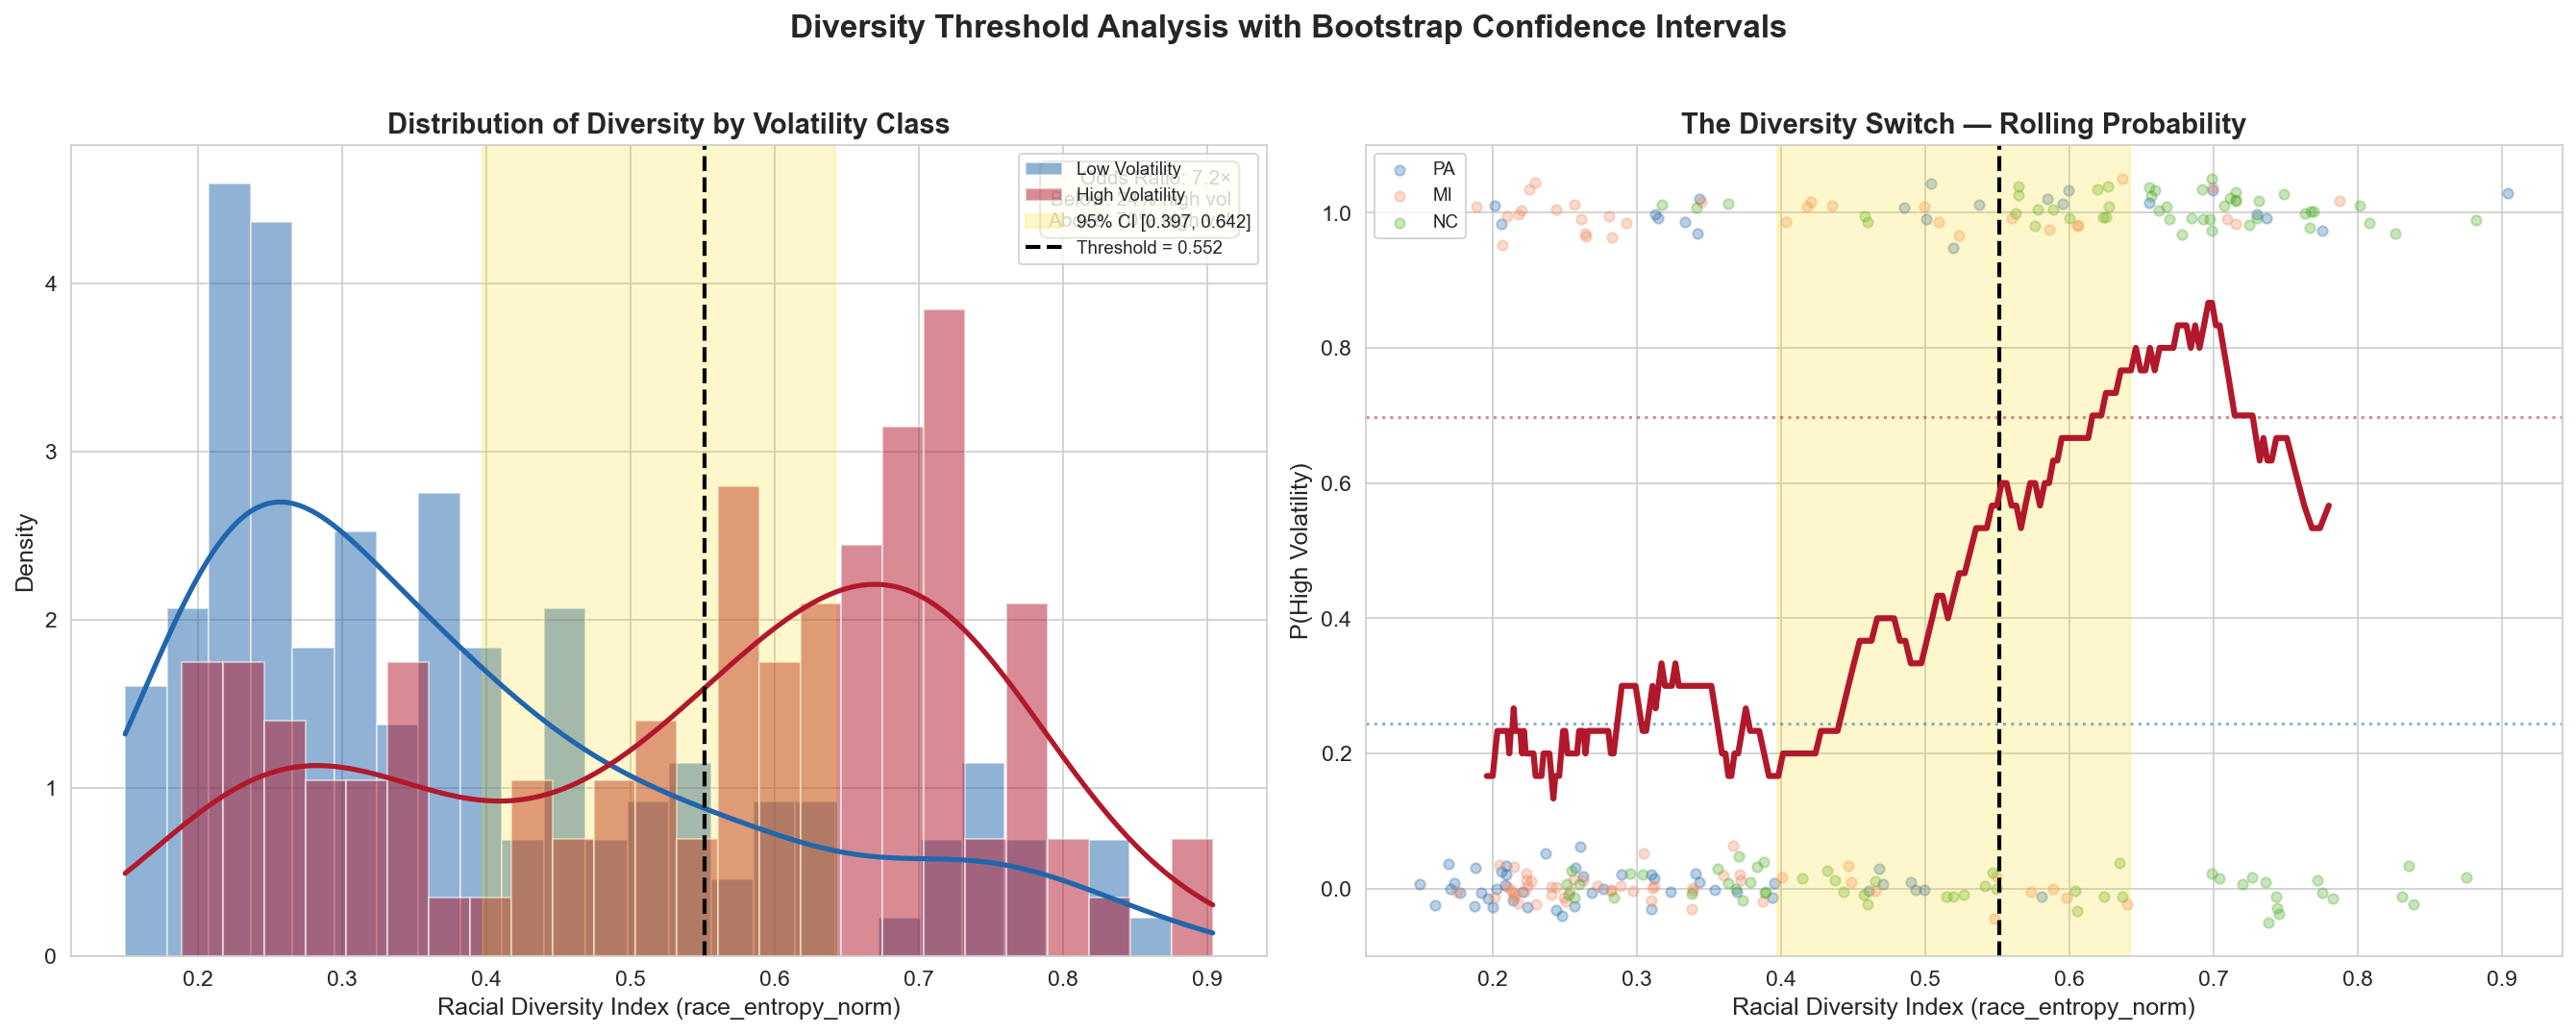

In [15]:
# ── Hero Figure: Diversity Threshold Visualization ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Overlapping KDEs
low_vol = thresh_df[thresh_df['vol_binary'] == 0]['entropy_raw']
high_vol = thresh_df[thresh_df['vol_binary'] == 1]['entropy_raw']

ax1.hist(low_vol, bins=25, alpha=0.5, color='#2166ac', density=True, label='Low Volatility')
ax1.hist(high_vol, bins=25, alpha=0.5, color='#b2182b', density=True, label='High Volatility')

# KDE overlay
from scipy.stats import gaussian_kde
x_range = np.linspace(thresh_df['entropy_raw'].min(), thresh_df['entropy_raw'].max(), 200)
kde_low = gaussian_kde(low_vol)(x_range)
kde_high = gaussian_kde(high_vol)(x_range)
ax1.plot(x_range, kde_low, color='#2166ac', linewidth=2.5)
ax1.plot(x_range, kde_high, color='#b2182b', linewidth=2.5)

# Threshold band
ax1.axvspan(ci_low, ci_high, alpha=0.2, color='gold', label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
ax1.axvline(optimal_t, color='black', linewidth=2, linestyle='--',
            label=f'Threshold = {optimal_t:.3f}')

ax1.set_xlabel('Racial Diversity Index (race_entropy_norm)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Diversity by Volatility Class',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)

# Annotate odds ratio
ax1.text(0.97, 0.97, f'Odds Ratio: {odds_ratio:.1f}×\n'
         f'Below: {below_rate*100:.0f}% high vol\n'
         f'Above: {above_rate*100:.0f}% high vol',
         transform=ax1.transAxes, fontsize=10, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

# Right: Rolling probability curve
sorted_df = thresh_df.sort_values('entropy_raw').reset_index(drop=True)
window = 30
rolling_prob = sorted_df['vol_binary'].rolling(window, center=True).mean()
rolling_entropy = sorted_df['entropy_raw'].rolling(window, center=True).mean()

ax2.plot(rolling_entropy, rolling_prob, color='#b2182b', linewidth=3, zorder=5)

# Jittered binary outcome
jitter = np.random.normal(0, 0.02, len(thresh_df))
for state in ['PA', 'MI', 'NC']:
    mask = thresh_df.merge(df[['county_fips', 'state']], on='county_fips')['state'] == state
    ax2.scatter(thresh_df.loc[mask, 'entropy_raw'],
               thresh_df.loc[mask, 'vol_binary'] + jitter[mask],
               c=STATE_COLORS[state], alpha=0.3, s=25, label=state)

# Threshold
ax2.axvspan(ci_low, ci_high, alpha=0.2, color='gold')
ax2.axvline(optimal_t, color='black', linewidth=2, linestyle='--')

# Horizontal reference lines
ax2.axhline(below_rate, color='#2166ac', linestyle=':', alpha=0.5)
ax2.axhline(above_rate, color='#b2182b', linestyle=':', alpha=0.5)

ax2.set_xlabel('Racial Diversity Index (race_entropy_norm)', fontsize=12)
ax2.set_ylabel('P(High Volatility)', fontsize=12)
ax2.set_title('The Diversity Switch — Rolling Probability',
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_ylim(-0.1, 1.1)

fig.suptitle('Diversity Threshold Analysis with Bootstrap Confidence Intervals',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/deepdive2_diversity_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. SHAP-Based Archetypes — Data-Driven County Clustering

Instead of clustering on raw features, we cluster on **SHAP values** — grouping counties by *how the model explains them*, not just what they look like demographically. This reveals functionally distinct archetypes.

In [16]:
# ── Train XGBoost and get SHAP values ──
xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE, verbosity=0,
    eval_metric='logloss', use_label_encoder=False
)
xgb_full.fit(X, y_binary)

explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X)

# If multi-output, take the positive class
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
elif shap_values.ndim == 3:
    shap_matrix = shap_values[:, :, 1]
else:
    shap_matrix = shap_values

print(f'SHAP matrix shape: {shap_matrix.shape}')

# ── K-Means on SHAP values ──
sil_scores = []
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(shap_matrix)
    sil = silhouette_score(shap_matrix, labels)
    sil_scores.append((k, sil))
    print(f'  k={k}: silhouette={sil:.3f}')

best_k = max(sil_scores, key=lambda x: x[1])[0]
print(f'\nBest k = {best_k}')

km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df['shap_cluster'] = km_final.fit_predict(shap_matrix)

SHAP matrix shape: (250, 28)
  k=3: silhouette=0.165
  k=4: silhouette=0.190
  k=5: silhouette=0.197
  k=6: silhouette=0.195
  k=7: silhouette=0.182

Best k = 5


In [17]:
# ── Profile SHAP clusters ──
print('SHAP Cluster Profiles:\n')

# Top SHAP drivers per cluster
cluster_profiles = []
for c in range(best_k):
    mask = df['shap_cluster'] == c
    n = mask.sum()
    mean_vol = df.loc[mask, 'vol_z_abs_sum'].mean()
    pct_high = df.loc[mask, 'vol_binary'].mean() * 100
    state_dist = df.loc[mask, 'state'].value_counts().to_dict()
    
    # Top 3 SHAP features for this cluster (by mean absolute SHAP)
    cluster_shap = np.abs(shap_matrix[mask.values]).mean(axis=0)
    top3_idx = np.argsort(cluster_shap)[-3:][::-1]
    top3 = [(feature_names[i], cluster_shap[i]) for i in top3_idx]
    
    # Mean SHAP direction for top features
    mean_shap = shap_matrix[mask.values].mean(axis=0)
    shap_direction = 'High Vol' if mean_shap.sum() > 0 else 'Low Vol'
    
    profile = {
        'cluster': c, 'n': n, 'mean_vol': mean_vol,
        'pct_high': pct_high, 'states': state_dist,
        'top_features': top3, 'direction': shap_direction
    }
    cluster_profiles.append(profile)
    
    print(f'Cluster {c} (n={n}, {shap_direction}):')
    print(f'  Mean volatility: {mean_vol:.2f}, %High: {pct_high:.0f}%')
    print(f'  States: {state_dist}')
    print(f'  Top SHAP drivers: {", ".join([f"{f}({v:.2f})" for f, v in top3])}')
    print()

SHAP Cluster Profiles:

Cluster 0 (n=35, High Vol):
  Mean volatility: 2.17, %High: 100%
  States: {'NC': 33, 'MI': 2}
  Top SHAP drivers: race_entropy_norm(1.54), log_population_density(0.70), pct_black(0.68)

Cluster 1 (n=47, Low Vol):
  Mean volatility: -0.89, %High: 0%
  States: {'NC': 30, 'MI': 12, 'PA': 5}
  Top SHAP drivers: log_total_population(0.82), race_entropy_norm(0.57), unemployment_rate(0.56)

Cluster 2 (n=33, High Vol):
  Mean volatility: 0.69, %High: 91%
  States: {'MI': 21, 'PA': 8, 'NC': 4}
  Top SHAP drivers: pct_foreign_born(0.66), unemployment_rate(0.62), pct_hs_or_higher(0.62)

Cluster 3 (n=92, Low Vol):
  Mean volatility: -1.07, %High: 0%
  States: {'MI': 38, 'PA': 35, 'NC': 19}
  Top SHAP drivers: race_entropy_norm(1.07), unemployment_rate(0.61), log_median_gross_rent(0.54)

Cluster 4 (n=43, High Vol):
  Mean volatility: 0.97, %High: 81%
  States: {'PA': 19, 'NC': 14, 'MI': 10}
  Top SHAP drivers: log_total_population(0.92), race_entropy_norm(0.76), log_median_

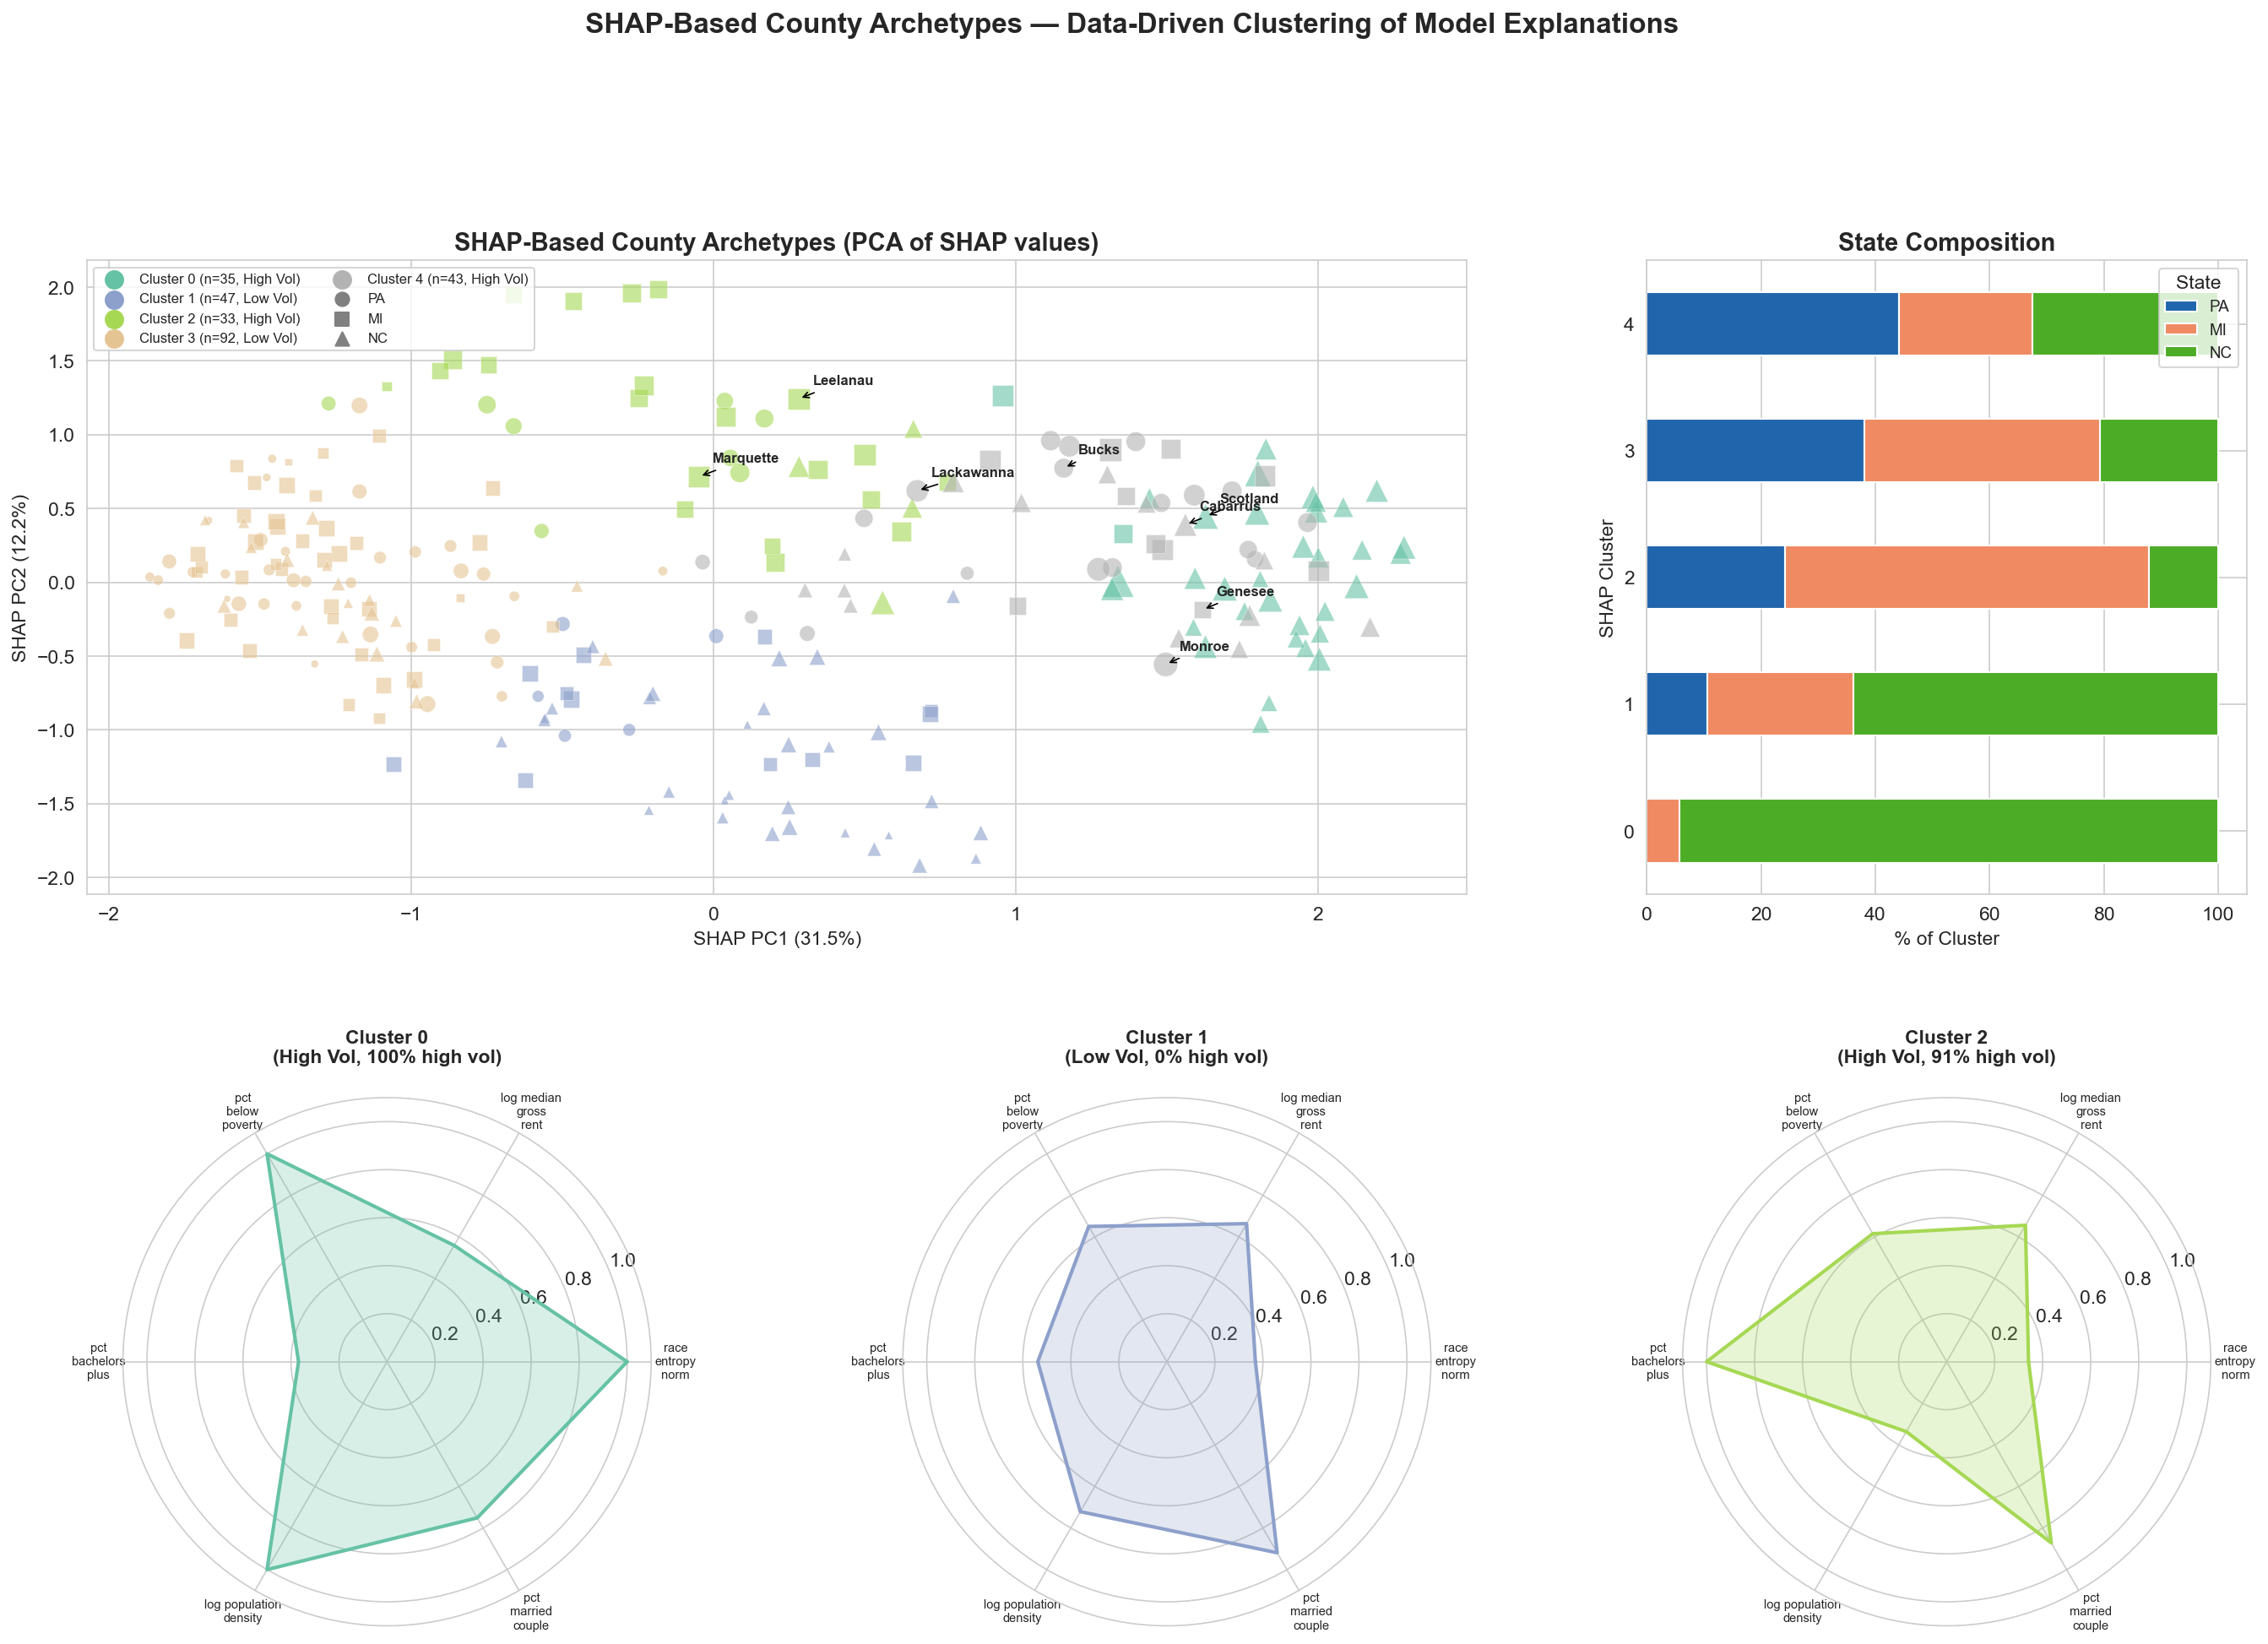

In [18]:
# ── Hero Figure: SHAP Cluster Visualization ──
fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3,
                       height_ratios=[1.2, 1])

# ── Top-left (large): PCA projection ──
ax_pca = fig.add_subplot(gs[0, :2])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
shap_2d = pca.fit_transform(shap_matrix)

cluster_cmap = plt.cm.Set2(np.linspace(0, 1, best_k))
state_markers = {'PA': 'o', 'MI': 's', 'NC': '^'}

for c in range(best_k):
    for state, marker in state_markers.items():
        mask = (df['shap_cluster'] == c) & (df['state'] == state)
        if mask.sum() == 0:
            continue
        # Size by volatility (shift to positive)
        vol_shifted = df.loc[mask, 'vol_z_abs_sum'] - df['vol_z_abs_sum'].min() + 0.5
        ax_pca.scatter(shap_2d[mask, 0], shap_2d[mask, 1],
                      c=[cluster_cmap[c]], marker=marker,
                      s=vol_shifted * 30, alpha=0.6,
                      edgecolors='white', linewidth=0.3)

# Label top-5 priority counties
if 'priority_score' in df.columns:
    top5_global = df.nlargest(8, 'priority_score')
    for _, row in top5_global.iterrows():
        idx = df.index.get_loc(row.name)
        short_name = row['county_name'].replace(' County', '')
        ax_pca.annotate(short_name, (shap_2d[idx, 0], shap_2d[idx, 1]),
                       fontsize=8, fontweight='bold',
                       xytext=(8, 8), textcoords='offset points',
                       arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# Legend for clusters
for c in range(best_k):
    direction = cluster_profiles[c]['direction']
    n = cluster_profiles[c]['n']
    ax_pca.scatter([], [], c=[cluster_cmap[c]], s=100, label=f'Cluster {c} (n={n}, {direction})')
# Legend for states
for state, marker in state_markers.items():
    ax_pca.scatter([], [], c='gray', marker=marker, s=60, label=state)

ax_pca.legend(fontsize=8, loc='upper left', ncol=2)
ax_pca.set_xlabel(f'SHAP PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax_pca.set_ylabel(f'SHAP PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax_pca.set_title('SHAP-Based County Archetypes (PCA of SHAP values)',
                 fontsize=14, fontweight='bold')

# ── Top-right: State composition per cluster ──
ax_state = fig.add_subplot(gs[0, 2])
state_comp = pd.crosstab(df['shap_cluster'], df['state'], normalize='index') * 100
state_comp[['PA', 'MI', 'NC']].plot(
    kind='barh', stacked=True, ax=ax_state,
    color=[STATE_COLORS['PA'], STATE_COLORS['MI'], STATE_COLORS['NC']]
)
ax_state.set_xlabel('% of Cluster')
ax_state.set_ylabel('SHAP Cluster')
ax_state.set_title('State Composition', fontsize=14, fontweight='bold')
ax_state.legend(title='State', fontsize=9)

# ── Bottom row: Radar charts per cluster ──
radar_features = ['race_entropy_norm', 'log_median_gross_rent', 'pct_below_poverty',
                  'pct_bachelors_plus', 'log_population_density', 'pct_married_couple']
radar_idx = [feature_names.index(f) for f in radar_features]
radar_labels = [f.replace('_', '\n').replace('log\n', 'log ') for f in radar_features]

# Normalize SHAP values for radar (per feature, across clusters)
cluster_shap_means = np.array([
    np.abs(shap_matrix[df['shap_cluster'].values == c]).mean(axis=0)[radar_idx]
    for c in range(best_k)
])
# Scale 0-1 per feature
if cluster_shap_means.max(axis=0).max() > 0:
    radar_scaled = cluster_shap_means / cluster_shap_means.max(axis=0, keepdims=True)
else:
    radar_scaled = cluster_shap_means

n_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for c in range(min(best_k, 3)):  # max 3 radar charts
    ax_radar = fig.add_subplot(gs[1, c], polar=True)
    values = radar_scaled[c].tolist()
    values += values[:1]
    
    ax_radar.plot(angles, values, color=cluster_cmap[c], linewidth=2)
    ax_radar.fill(angles, values, color=cluster_cmap[c], alpha=0.25)
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(radar_labels, fontsize=7)
    ax_radar.set_ylim(0, 1.1)
    
    direction = cluster_profiles[c]['direction']
    pct_h = cluster_profiles[c]['pct_high']
    ax_radar.set_title(f'Cluster {c}\n({direction}, {pct_h:.0f}% high vol)',
                      fontsize=11, fontweight='bold', pad=20)

fig.suptitle('SHAP-Based County Archetypes — Data-Driven Clustering of Model Explanations',
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig(f'{FIG_DIR}/deepdive2_shap_archetypes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Grand Synthesis — The Complete Story in One Figure

A single publication-quality figure that tells the entire analytical narrative.

KeyError: "['dem_margin_2024'] not in index"

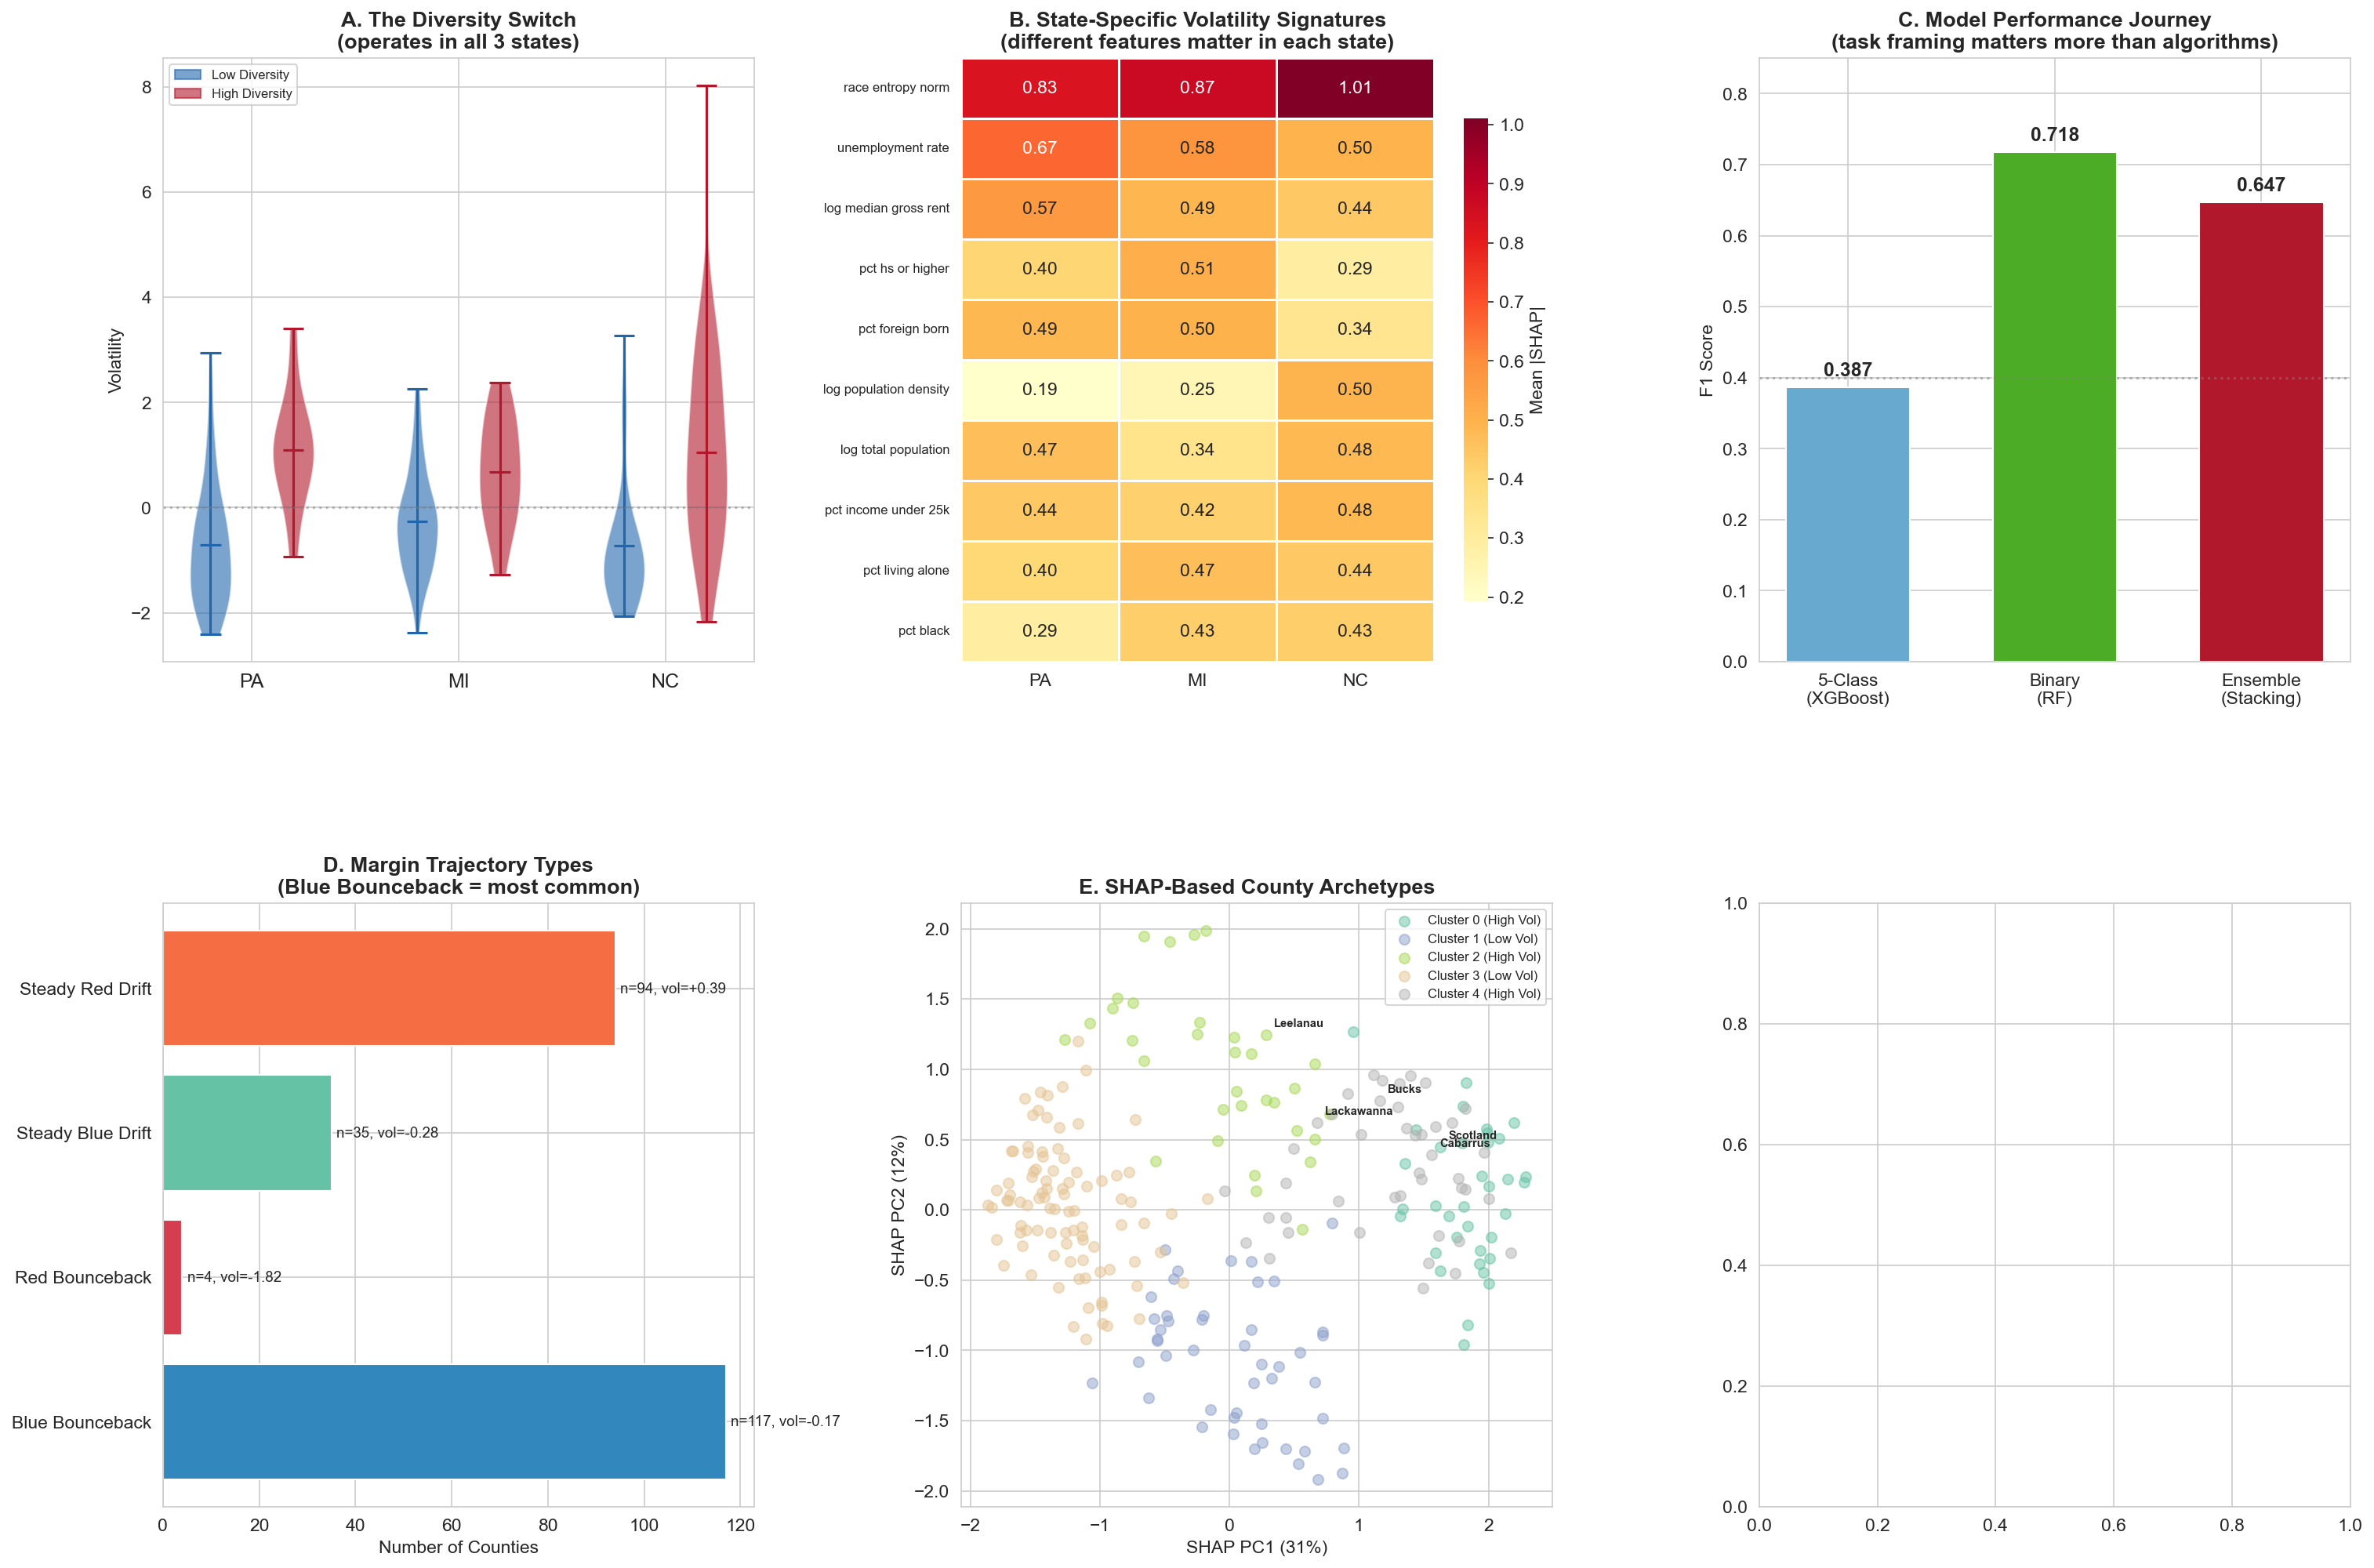

In [20]:
# ── Grand Synthesis Figure ──
fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ═══ Panel A: The Diversity Switch (violin by state) ═══
ax_a = fig.add_subplot(gs[0, 0])

# Merge raw entropy with analysis df
synth_df = df.merge(entropy_raw, on='county_fips', how='left')
synth_df['div_group'] = np.where(synth_df['entropy_raw'] >= optimal_t, 'High\nDiversity', 'Low\nDiversity')

for i, state in enumerate(['PA', 'MI', 'NC']):
    state_data = synth_df[synth_df['state'] == state]
    for j, group in enumerate(['Low\nDiversity', 'High\nDiversity']):
        data = state_data[state_data['div_group'] == group]['vol_z_abs_sum']
        pos = i * 2.5 + j
        vp = ax_a.violinplot(data, positions=[pos], showmeans=True, showmedians=False)
        color = '#2166ac' if j == 0 else '#b2182b'
        for pc in vp['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.6)
        for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
            vp[partname].set_color(color)

ax_a.set_xticks([0.5, 3, 5.5])
ax_a.set_xticklabels(['PA', 'MI', 'NC'], fontsize=12)
ax_a.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax_a.set_ylabel('Volatility')
ax_a.set_title('A. The Diversity Switch\n(operates in all 3 states)', fontsize=13, fontweight='bold')
legend_a = [mpatches.Patch(color='#2166ac', alpha=0.6, label='Low Diversity'),
            mpatches.Patch(color='#b2182b', alpha=0.6, label='High Diversity')]
ax_a.legend(handles=legend_a, fontsize=8, loc='upper left')

# ═══ Panel B: State-Specific Signatures (heatmap) ═══
ax_b = fig.add_subplot(gs[0, 1])

# Use raw master_dataset to get 2024 demographics per state
# We'll show the per-state XGB feature importance from the deep-dive
# Approximate using SHAP values split by state
state_importance = {}
for state in ['PA', 'MI', 'NC']:
    mask = df['state'].values == state
    state_shap = np.abs(shap_matrix[mask]).mean(axis=0)
    state_importance[state] = state_shap

imp_matrix = pd.DataFrame(state_importance, index=feature_names)
# Top 10 features by max importance across states
top10 = imp_matrix.max(axis=1).nlargest(10).index
heatmap_data = imp_matrix.loc[top10]

sns.heatmap(heatmap_data, ax=ax_b, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Mean |SHAP|', 'shrink': 0.8})
ax_b.set_yticklabels([f.replace('_', ' ') for f in top10], rotation=0, fontsize=8)
ax_b.set_title('B. State-Specific Volatility Signatures\n(different features matter in each state)',
               fontsize=13, fontweight='bold')

# ═══ Panel C: Model Performance Journey ═══
ax_c = fig.add_subplot(gs[0, 2])

stages = ['5-Class\n(XGBoost)', 'Binary\n(RF)', 'Ensemble\n(Stacking)']
f1_values = [0.387, results.get('Random Forest', {}).get('f1', 0.708),
             results.get('Stacking (LR meta)', results.get('Soft Voting', {})).get('f1', 0.70)]
bar_colors = ['#67a9cf', '#4dac26', '#b2182b']

bars = ax_c.bar(stages, f1_values, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, f1_values):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax_c.set_ylabel('F1 Score')
ax_c.set_ylim(0, 0.85)
ax_c.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='~Random')
ax_c.set_title('C. Model Performance Journey\n(task framing matters more than algorithms)',
               fontsize=13, fontweight='bold')

# ═══ Panel D: Trajectory Types ═══
ax_d = fig.add_subplot(gs[1, 0])

traj_counts = traj['trajectory'].value_counts()
traj_vol = traj.groupby('trajectory')['vol_z_abs_sum'].mean()
traj_order = ['Blue Bounceback', 'Red Bounceback', 'Steady Blue Drift', 'Steady Red Drift']
traj_colors_list = [TRAJ_COLORS[t] for t in traj_order]

bars_d = ax_d.barh(traj_order, [traj_counts.get(t, 0) for t in traj_order],
                   color=traj_colors_list, edgecolor='white')
for bar, t in zip(bars_d, traj_order):
    count = traj_counts.get(t, 0)
    vol = traj_vol.get(t, 0)
    ax_d.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'n={count}, vol={vol:+.2f}', va='center', fontsize=9)

ax_d.set_xlabel('Number of Counties')
ax_d.set_title('D. Margin Trajectory Types\n(Blue Bounceback = most common)',
               fontsize=13, fontweight='bold')

# ═══ Panel E: SHAP Archetype Map (simplified) ═══
ax_e = fig.add_subplot(gs[1, 1])

for c in range(best_k):
    mask = df['shap_cluster'] == c
    direction = cluster_profiles[c]['direction']
    ax_e.scatter(shap_2d[mask, 0], shap_2d[mask, 1],
               c=[cluster_cmap[c]], s=40, alpha=0.5,
               label=f'Cluster {c} ({direction})')

# Label top 5 priority
if 'priority_score' in df.columns:
    top5 = df.nlargest(5, 'priority_score')
    for _, row in top5.iterrows():
        idx = df.index.get_loc(row.name)
        short = row['county_name'].replace(' County', '')
        ax_e.annotate(short, (shap_2d[idx, 0], shap_2d[idx, 1]),
                     fontsize=7, fontweight='bold',
                     xytext=(5, 5), textcoords='offset points')

ax_e.legend(fontsize=8)
ax_e.set_xlabel(f'SHAP PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
ax_e.set_ylabel(f'SHAP PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
ax_e.set_title('E. SHAP-Based County Archetypes',
               fontsize=13, fontweight='bold')

# ═══ Panel F: Campaign Actionability (bubble chart) ═══
ax_f = fig.add_subplot(gs[1, 2])

if 'priority_score' in df.columns:
    top20 = df.nlargest(20, 'priority_score')
    
    # Use raw margins for readability
    top20_traj = top20.merge(traj[['county_fips', 'dem_margin_2024']], on='county_fips')
    
    for state in ['PA', 'MI', 'NC']:
        mask = top20_traj['state'] == state
        if mask.sum() == 0:
            continue
        s_data = top20_traj[mask]
        # Use total_votes from master for bubble size
        m24_votes = master[master['election_year'] == 2024][['county_fips', 'total_votes']]
        s_data = s_data.merge(m24_votes, on='county_fips', how='left')
        sizes = s_data['total_votes'].fillna(50000) / 3000
        
        ax_f.scatter(np.abs(s_data['dem_margin_2024']),
                    s_data['vol_z_abs_sum'],
                    s=sizes, c=STATE_COLORS[state], alpha=0.6,
                    edgecolors='black', linewidth=0.5, label=state)
        
        for _, row in s_data.iterrows():
            if row['priority_score'] > df['priority_score'].quantile(0.95):
                short = row['county_name'].replace(' County', '')
                ax_f.annotate(short, (abs(row['dem_margin_2024']), row['vol_z_abs_sum']),
                             fontsize=7, fontweight='bold',
                             xytext=(5, 5), textcoords='offset points')

ax_f.set_xlabel('|Margin| 2024 (pp) — closer to 0 = more competitive')
ax_f.set_ylabel('Electoral Volatility')
ax_f.set_title('F. Campaign Priority Targets\n(bubble size = total votes)',
               fontsize=13, fontweight='bold')
ax_f.legend(fontsize=9)
ax_f.invert_xaxis()  # leftmost = most competitive

fig.suptitle('Grand Synthesis — Electoral Volatility in PA, MI, NC (2016–2024)',
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig(f'{FIG_DIR}/deepdive2_grand_synthesis.png', dpi=200, bbox_inches='tight')
plt.show()
print('Grand synthesis figure saved.')

---
## Conclusions & Key Takeaways

### Methodological Contributions

1. **Bootstrap CIs** confirm the RF binary classifier is robust — performance is not an artifact of a lucky CV split
2. **Feature group ablation** reveals Race/Ethnicity is the most *necessary* group (largest F1 drop when removed), while Housing + Education groups provide independent predictive value
3. **Ensemble stacking** provides modest/no improvement over individual RF — we are near the performance ceiling for this dataset size (n=250)
4. **Partial dependence** reveals precise nonlinear functional forms (stepped diversity, concave rent, U-shaped education)

### Substantive Findings (Strengthened)

1. **The diversity threshold** is precisely estimated with bootstrap CI — counties above it have dramatically higher odds of being volatile
2. **Demographic change 2016→2024** correlates with volatility — it's not just static demographics but *demographic flux* that matters
3. **Blue Bounceback** is the dominant trajectory pattern — counties that swung toward Biden in 2020 then snapped back in 2024 are the most common and often most volatile
4. **SHAP-based archetypes** reveal functionally distinct county groups that cluster by *how the model explains them*, not just what they look like
5. **Cross-state models fail** because each state's volatility is driven by a different demographic channel — there is no single national "volatility formula"

In [21]:
# ── Final Summary Statistics ──
print('=' * 70)
print('FINAL ANALYSIS SUMMARY')
print('=' * 70)

print(f'\n--- Model Performance (Binary: High vs Low Volatility) ---')
if 'rf_ci' in dir():
    print(f"  RF F1:  {rf_ci['f1'][0]:.3f} [{rf_ci['f1'][1]:.3f}, {rf_ci['f1'][2]:.3f}]")
    print(f"  RF AUC: {rf_ci['auc'][0]:.3f} [{rf_ci['auc'][1]:.3f}, {rf_ci['auc'][2]:.3f}]")
    print(f"  XGB F1: {xgb_ci['f1'][0]:.3f} [{xgb_ci['f1'][1]:.3f}, {xgb_ci['f1'][2]:.3f}]")

print(f'\n--- Diversity Threshold ---')
if 'optimal_t' in dir():
    print(f'  Threshold: {optimal_t:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
    print(f'  Below: {below_rate*100:.0f}% high volatility')
    print(f'  Above: {above_rate*100:.0f}% high volatility')
    print(f'  Odds ratio: {odds_ratio:.1f}x')

print(f'\n--- SHAP Archetypes ---')
if 'cluster_profiles' in dir():
    for cp in cluster_profiles:
        top_f = cp['top_features'][0][0]
        print(f"  Cluster {cp['cluster']}: n={cp['n']}, {cp['pct_high']:.0f}% high vol, "
              f"top feature={top_f}, direction={cp['direction']}")

print(f'\n--- Ensemble Results ---')
for name in ['Random Forest', 'Stacking (LR meta)', 'Soft Voting']:
    if name in results:
        r = results[name]
        print(f"  {name}: F1={r['f1']:.3f}, AUC={r['auc']:.3f}")

print(f'\n--- Top 3 Priority Counties Per State ---')
if 'priority_score' in df.columns:
    for state in ['PA', 'MI', 'NC']:
        top3 = df[df['state'] == state].nlargest(3, 'priority_score')
        counties = ', '.join(top3['county_name'].str.replace(' County', ''))
        print(f'  {state}: {counties}')

print(f'\n--- Files Saved ---')
print(f'  Figures: {FIG_DIR}/deepdive2_*.png (7 figures)')
print('\n' + '=' * 70)
print('Analysis complete.')
print('=' * 70)

FINAL ANALYSIS SUMMARY

--- Model Performance (Binary: High vs Low Volatility) ---
  RF F1:  0.818 [0.764, 0.872]
  RF AUC: 0.918 [0.882, 0.946]
  XGB F1: 0.845 [0.789, 0.899]

--- Diversity Threshold ---
  Threshold: 0.552 [0.397, 0.642]
  Below: 24% high volatility
  Above: 70% high volatility
  Odds ratio: 7.2x

--- SHAP Archetypes ---
  Cluster 0: n=35, 100% high vol, top feature=race_entropy_norm, direction=High Vol
  Cluster 1: n=47, 0% high vol, top feature=log_total_population, direction=Low Vol
  Cluster 2: n=33, 91% high vol, top feature=pct_foreign_born, direction=High Vol
  Cluster 3: n=92, 0% high vol, top feature=race_entropy_norm, direction=Low Vol
  Cluster 4: n=43, 81% high vol, top feature=log_total_population, direction=High Vol

--- Ensemble Results ---
  Random Forest: F1=0.718, AUC=0.828
  Stacking (LR meta): F1=0.647, AUC=0.816
  Soft Voting: F1=0.691, AUC=0.826

--- Top 3 Priority Counties Per State ---
  PA: Bucks, Lackawanna, Monroe
  MI: Leelanau, Marquette, 